# 社群媒體分析-期末報告 第25組
M144020052 張恩誠
M144020056 張祐豪

#主題 : PTT對於台灣交通安全與行人路權議題的社群輿情分析

# A. 動機和分析目的

近年台灣社會對交通安全與行人路權的討論逐漸增加，許多民眾在社群平台上討論行人過馬路安全、斑馬線禮讓、違停、機車與汽車駕駛行為、道路設計、執法強度與交通事故等問題。交通安全不只是交通管理問題，也牽涉到日常通勤、城市規劃、道路使用者權益、公共政策與社會安全感。因此，本專案選擇以 PTT 公開文章作為資料來源，分析台灣網路社群如何討論交通安全與行人路權議題。

本專案的分析目的有三個。第一，透過爬蟲方式蒐集 PTT 上與交通安全相關的公開文章，建立可分析的文字資料集。第二，依據文章內容將討論分成數個子議題類別，例如行人路權與安全、駕駛違規與行為、道路設計與基礎建設、公共運輸與通勤、執法與政策、事故與新聞事件等，以觀察社群討論焦點集中在哪些面向。第三，後續將進行情緒分析與視覺化，觀察不同子議題下的討論量、推噓反應與情緒傾向是否存在差異。

本研究的核心問題為：「PTT 使用者如何討論台灣交通安全與行人路權議題？不同子議題的討論量與情緒反應是否存在差異？」透過此問題，本專案可以將課堂中的社群媒體資料蒐集、文字分類、主題分類與情緒分析方法應用在台灣社會議題上。

# B. 資料集的描述

本專案資料來源為 PTT 網頁版公開文章，主要蒐集與「行人、行人地獄、交通安全、斑馬線、人行道、違停、酒駕、車禍、交通事故、機車、汽車、測速、罰則」等關鍵字相關的文章。選擇 PTT 作為資料來源的原因，是 PTT 具有公開文章列表、文章標題、發文時間、看板、推噓文資訊與文章內文，適合用於社群媒體分析。相較於新聞報導，PTT 更能反映一般使用者對社會議題的即時感受、批評、經驗分享與討論語氣。

本專案預計蒐集的看板包含 Gossiping、car、biker、HatePolitics 與 Road。Gossiping 屬於綜合討論看板，可以觀察一般大眾對交通安全事件的反應；car 與汽車駕駛、道路使用經驗相關，可以觀察駕駛者觀點；biker 與機車族通勤、道路風險及交通規則相關，可以觀察機車使用者觀點；HatePolitics 可補充政策、政府治理與政治責任討論；Road 則可補充道路設計與交通建設面向。這些看板的組合能讓資料同時涵蓋一般輿論、駕駛者經驗、機車族觀點、政策討論與道路設計觀點。

時間範圍設定為近六個月。選擇近六個月的理由有三點。第一，交通安全議題容易受到近期事故、政策修法、執法強度與新聞事件影響，因此使用近期資料較能反映目前社會討論狀態。第二，若只取一個月資料，可能會過度受到單一重大交通事件影響，導致分析結果偏向特定事件；近六個月可以降低單一事件造成的偏誤。第三，六個月的資料量通常足以進行文字分類與視覺化分析，同時也能控制 Colab 爬蟲與資料處理的執行時間。因此，本專案以近六個月作為主要分析範圍，並在程式中記錄實際資料蒐集日期。

本資料集預計包含以下欄位：看板名稱、搜尋關鍵字、文章標題、文章日期、文章網址、匿名化作者、文章內文、推文數、噓文數、中立留言數、主要議題類別、所有命中的議題類別、命中的關鍵字、文章字數、資料蒐集時間等。為了降低個人資料風險，本專案不直接保存原始作者帳號，而是使用雜湊方式產生匿名作者代碼。

資料時間範圍是 2025 年 12 月 27 日到 2026 年 6 月 22 日，大約涵蓋近六個月的討論。原本初步搜尋到 2051 篇文章，經過文章讀取、時間篩選、去除重複網址，以及交通安全相關性過濾後，最後得到 772 筆有效文章。資料品質檢查結果顯示，重複網址數、空白內文數與缺失日期數都是 0，因此資料品質足以進行後續分析。

在資料來源分布上，Gossiping 有 433 篇，是最多的，占整體一半以上。HatePolitics 有 186 篇，car 有 114 篇，biker 有 28 篇，Road 有 11 篇。這表示交通安全與行人路權議題在 PTT 上主要是由一般大眾討論和政治政策討論帶動，而汽機車看板則提供道路使用者的補充觀點。

In [5]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')


In [6]:
!pip -q install requests beautifulsoup4 pandas tqdm

import re
import time
import hashlib
from pathlib import Path
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from urllib.parse import quote, urljoin
from email.utils import parsedate_to_datetime

import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm import tqdm
from IPython.display import display

本儲存格的目的是定義本研究的資料蒐集範圍。首先設定專案名稱與資料儲存位置，讓後續產生的資料集與分析結果可以被有系統地保存。接著設定分析時間範圍為近六個月，原因是交通安全與行人路權屬於容易受到近期事故、政策修法與新聞事件影響的社會議題，使用近期資料較能反映目前社群討論狀況；但若只抓一個月資料，又可能受到單一事件影響，因此選擇近六個月作為兼顧時效性與資料量的範圍。

本儲存格也設定要蒐集的 PTT 看板與搜尋關鍵字。選擇 Gossiping、car、biker、HatePolitics 與 Road 等看板，是為了讓資料涵蓋一般大眾、汽車駕駛、機車族、政策討論與道路設計等不同觀點。搜尋關鍵字則圍繞交通安全、行人路權、違規駕駛、車禍事故與公共運輸等核心議題，確保蒐集到的文章與研究主題具有相關性。

In [7]:
PROJECT_NAME = "PTT 對台灣交通安全與行人路權議題的社群輿情分析"

PROJECT_DIR = Path("/content/ptt_traffic_safety_project")
DATA_DIR = PROJECT_DIR / "dataset"
OUTPUT_DIR = PROJECT_DIR / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 預設抓近六個月
today_tw = datetime.now(ZoneInfo("Asia/Taipei")).date()
END_DATE = today_tw
START_DATE = END_DATE - timedelta(days=180)

print("專案名稱：", PROJECT_NAME)
print("資料起日：", START_DATE)
print("資料迄日：", END_DATE)

# 看板設定
BOARDS = [
    "Gossiping",     # 一般大眾討論
    "car",           # 汽車與駕駛觀點
    "biker",         # 機車族與通勤經驗
    "HatePolitics",  # 政策與政治責任討論
    "Road"           # 道路設計與交通建設，若看板不存在程式會略過
]

# 搜尋關鍵字
SEARCH_KEYWORDS = [
    "交通安全",
    "行人",
    "行人地獄",
    "斑馬線",
    "人行道",
    "違停",
    "酒駕",
    "車禍",
    "交通事故",
    "測速",
    "罰則",
    "機車",
    "汽車",
    "公車",
    "捷運"
]

# 每個看板、每個關鍵字最多抓幾頁搜尋結果
# 若資料太少可以調大，例如 3 或 5
MAX_SEARCH_PAGES_PER_KEYWORD = 2

# 每次 request 的間隔秒數，避免太密集請求
REQUEST_DELAY = 0.35

專案名稱： PTT 對台灣交通安全與行人路權議題的社群輿情分析
資料起日： 2025-12-25
資料迄日： 2026-06-23


本儲存格的目的是建立本研究的初步議題分類架構。交通安全並不是單一面向的問題，不同文章可能討論行人路權、駕駛違規、道路設計、公共運輸、政府政策或交通事故。如果不先建立分類架構，後續分析只會得到整體討論量，較難看出社群真正關注哪些面向。

因此，本研究先以關鍵字字典建立六個子議題類別，包含「行人路權與安全」、「駕駛違規與行為」、「道路設計與基礎建設」、「公共運輸與通勤」、「執法與政策」以及「事故與新聞事件」。這樣做可以讓後續分析比較不同子議題的文章數量、推噓反應與情緒傾向，也能讓研究結果更有解釋力。

In [8]:
TOPIC_LEXICON = {
    "行人路權與安全": [
        "行人", "行人地獄", "斑馬線", "禮讓", "過馬路", "行人穿越道",
        "人行道", "庇護島", "行人號誌", "行人安全", "路權"
    ],
    "駕駛違規與行為": [
        "違停", "闖紅燈", "酒駕", "超速", "逼車", "未禮讓",
        "紅燈右轉", "違規", "三寶", "危險駕駛", "飆車", "檢舉"
    ],
    "道路設計與基礎建設": [
        "道路設計", "標線", "號誌", "路口", "車道", "人行空間",
        "交通工程", "道路規劃", "路燈", "騎樓", "停車格", "分隔島"
    ],
    "公共運輸與通勤": [
        "公車", "捷運", "台鐵", "高鐵", "通勤", "轉乘", "班距",
        "大眾運輸", "YouBike", "自行車", "共享運具"
    ],
    "執法與政策": [
        "罰則", "執法", "警察", "交通部", "市政府", "修法",
        "政策", "罰單", "科技執法", "測速", "交通安全月"
    ],
    "事故與新聞事件": [
        "車禍", "死亡", "受傷", "事故", "撞", "肇事", "擦撞",
        "追撞", "新聞", "影片", "監視器", "送醫"
    ]
}

# 合併所有議題詞，方便找文章命中的交通相關字
ALL_TOPIC_WORDS = sorted(set(
    word for words in TOPIC_LEXICON.values() for word in words
))

本儲存格的目的是準備資料蒐集所需的爬蟲功能。由於本研究資料來自 PTT 公開文章，因此需要建立一組可以搜尋文章、讀取文章內容、取得發文日期、統計推噓文數量與整理文章資訊的工具。這一步本身還不會正式產生資料集，而是先建立後續蒐集資料時會用到的功能。

此外，本專案也在這個階段加入作者匿名化處理，避免直接保存原始帳號，降低個人資料風險。這對社群媒體分析很重要，因為本研究的重點是分析整體輿情與議題趨勢，而不是分析特定個人的行為。

In [9]:
BASE_URL = "https://www.ptt.cc"

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/120 Safari/537.36"
})

# Gossiping 等限制級看板需要 over18 cookie
session.cookies.set("over18", "1")


def safe_get(url, timeout=15):
    """
    安全取得網頁。
    回傳 requests.Response 或 None。
    """
    try:
        time.sleep(REQUEST_DELAY)
        resp = session.get(url, timeout=timeout)
        if resp.status_code == 200:
            return resp
        else:
            print(f"HTTP {resp.status_code}: {url}")
            return None
    except Exception as e:
        print(f"Request error: {url} | {e}")
        return None


def parse_ptt_datetime(date_str):
    """
    解析 PTT 文章時間格式。
    例如：Fri Jun 21 12:34:56 2026
    """
    if not date_str:
        return None

    date_str = date_str.strip()

    try:
        dt = datetime.strptime(date_str, "%a %b %d %H:%M:%S %Y")
        return dt.replace(tzinfo=ZoneInfo("Asia/Taipei"))
    except Exception:
        return None


def anonymize_author(author):
    """
    將作者帳號雜湊化，避免直接保存原始帳號。
    """
    if not author or author == "unknown":
        return "unknown"

    salt = "traffic_safety_final_project"
    text = f"{salt}_{author}"
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:12]


def parse_nrec(nrec_text):
    """
    解析 PTT 列表中的推文數。
    爆 = 100
    X1, X2 等負評先轉成負數
    """
    if not nrec_text:
        return 0

    nrec_text = nrec_text.strip()

    if nrec_text == "爆":
        return 100

    if nrec_text.startswith("X"):
        try:
            return -int(nrec_text.replace("X", ""))
        except:
            return -1

    try:
        return int(nrec_text)
    except:
        return 0


def get_search_entries(board, keyword, max_pages=2):
    """
    從 PTT 搜尋頁取得文章列表。
    """
    first_url = f"{BASE_URL}/bbs/{board}/search?q={quote(keyword)}"
    url = first_url

    entries = []

    for page_i in range(max_pages):
        resp = safe_get(url)
        if resp is None:
            break

        soup = BeautifulSoup(resp.text, "html.parser")

        # 若看板不存在或被導向其他頁面，通常抓不到 r-ent
        rent_list = soup.select("div.r-ent")

        for r in rent_list:
            title_tag = r.select_one("div.title a")
            if not title_tag:
                continue

            title = title_tag.get_text(strip=True)
            href = title_tag.get("href")
            article_url = urljoin(BASE_URL, href)

            author_tag = r.select_one("div.author")
            date_tag = r.select_one("div.date")
            nrec_tag = r.select_one("div.nrec")

            entries.append({
                "board": board,
                "search_keyword": keyword,
                "title": title,
                "url": article_url,
                "list_author": author_tag.get_text(strip=True) if author_tag else "",
                "list_date": date_tag.get_text(strip=True) if date_tag else "",
                "list_nrec": parse_nrec(nrec_tag.get_text(strip=True) if nrec_tag else "")
            })

        # 找搜尋結果的上一頁
        prev_link = None
        for a in soup.select("a.btn.wide"):
            if "上頁" in a.get_text():
                prev_link = a.get("href")
                break

        if prev_link:
            url = urljoin(BASE_URL, prev_link)
        else:
            break

    return entries


def parse_article(article_url):
    """
    解析單篇 PTT 文章內容。
    """
    resp = safe_get(article_url)
    if resp is None:
        return None

    soup = BeautifulSoup(resp.text, "html.parser")
    main = soup.find(id="main-content")
    if main is None:
        return None

    # 解析 meta 資訊
    meta = {}
    for line in main.select("div.article-metaline"):
        tag = line.select_one("span.article-meta-tag")
        value = line.select_one("span.article-meta-value")
        if tag and value:
            meta[tag.get_text(strip=True)] = value.get_text(strip=True)

    author_raw = meta.get("作者", "")
    title_raw = meta.get("標題", "")
    date_raw = meta.get("時間", "")

    # 推噓文統計
    push_count = 0
    boo_count = 0
    neutral_count = 0

    for push in main.select("div.push"):
        tag = push.select_one("span.push-tag")
        tag_text = tag.get_text(strip=True) if tag else ""

        if "推" in tag_text:
            push_count += 1
        elif "噓" in tag_text:
            boo_count += 1
        else:
            neutral_count += 1

    # 移除 meta、推文、站方資訊
    for tag in main.select("div.article-metaline, div.article-metaline-right, div.push, span.f2"):
        tag.decompose()

    content = main.get_text("\n", strip=True)

    # 移除常見分隔線後內容
    content = re.split(r"--\s*\n", content)[0]
    content = re.split(r"※ 發信站:", content)[0]
    content = content.strip()

    article_dt = parse_ptt_datetime(date_raw)

    return {
        "author_raw": author_raw,
        "author_hash": anonymize_author(author_raw),
        "article_title": title_raw,
        "article_datetime": article_dt,
        "article_date": article_dt.date() if article_dt else None,
        "content": content,
        "push_count": push_count,
        "boo_count": boo_count,
        "neutral_count": neutral_count
    }


def classify_topic(text):
    """
    根據議題字典分類文章。
    回傳主要議題、所有命中議題、命中詞。
    """
    if not isinstance(text, str):
        text = ""

    topic_scores = {}
    topic_hit_words = {}

    for topic, words in TOPIC_LEXICON.items():
        hits = []
        score = 0

        for w in words:
            count = text.count(w)
            if count > 0:
                score += count
                hits.append(w)

        if score > 0:
            topic_scores[topic] = score
            topic_hit_words[topic] = hits

    if not topic_scores:
        return "其他／未分類", "", ""

    main_topic = max(topic_scores, key=topic_scores.get)
    all_topics = "、".join(topic_scores.keys())

    all_hit_words = []
    for words in topic_hit_words.values():
        all_hit_words.extend(words)

    all_hit_words = "、".join(sorted(set(all_hit_words)))

    return main_topic, all_topics, all_hit_words

本儲存格的目的是依據前面設定的看板與關鍵字，正式從 PTT 搜尋相關文章列表。這一步會先蒐集文章的基本資訊，例如看板、搜尋關鍵字、文章標題、文章網址與列表上的推文數。這些文章列表是後續進一步讀取文章內文的基礎。

在這個階段先取得文章列表，而不是一開始就直接分析內文，是為了先確認是否有足夠資料，以及避免重複抓取相同文章。由於同一篇文章可能同時命中多個關鍵字，因此本儲存格也會去除重複網址，讓後續資料集不會因為重複文章而影響分析結果。

In [10]:
all_entries = []

for board in BOARDS:
    for keyword in SEARCH_KEYWORDS:
        print(f"搜尋看板={board}, 關鍵字={keyword}")
        entries = get_search_entries(
            board=board,
            keyword=keyword,
            max_pages=MAX_SEARCH_PAGES_PER_KEYWORD
        )
        all_entries.extend(entries)

print("搜尋列表取得筆數：", len(all_entries))

entries_df = pd.DataFrame(all_entries)

if len(entries_df) > 0:
    entries_df = entries_df.drop_duplicates(subset=["url"]).reset_index(drop=True)

print("去除重複 URL 後筆數：", len(entries_df))
display(entries_df.head())

搜尋看板=Gossiping, 關鍵字=交通安全
搜尋看板=Gossiping, 關鍵字=行人
搜尋看板=Gossiping, 關鍵字=行人地獄
搜尋看板=Gossiping, 關鍵字=斑馬線
搜尋看板=Gossiping, 關鍵字=人行道
搜尋看板=Gossiping, 關鍵字=違停
搜尋看板=Gossiping, 關鍵字=酒駕
搜尋看板=Gossiping, 關鍵字=車禍
搜尋看板=Gossiping, 關鍵字=交通事故
搜尋看板=Gossiping, 關鍵字=測速
搜尋看板=Gossiping, 關鍵字=罰則
搜尋看板=Gossiping, 關鍵字=機車
搜尋看板=Gossiping, 關鍵字=汽車
搜尋看板=Gossiping, 關鍵字=公車
搜尋看板=Gossiping, 關鍵字=捷運
搜尋看板=car, 關鍵字=交通安全
搜尋看板=car, 關鍵字=行人
搜尋看板=car, 關鍵字=行人地獄
搜尋看板=car, 關鍵字=斑馬線
搜尋看板=car, 關鍵字=人行道
搜尋看板=car, 關鍵字=違停
搜尋看板=car, 關鍵字=酒駕
搜尋看板=car, 關鍵字=車禍
搜尋看板=car, 關鍵字=交通事故
搜尋看板=car, 關鍵字=測速
搜尋看板=car, 關鍵字=罰則
搜尋看板=car, 關鍵字=機車
搜尋看板=car, 關鍵字=汽車
搜尋看板=car, 關鍵字=公車
搜尋看板=car, 關鍵字=捷運
搜尋看板=biker, 關鍵字=交通安全
搜尋看板=biker, 關鍵字=行人
搜尋看板=biker, 關鍵字=行人地獄
搜尋看板=biker, 關鍵字=斑馬線
搜尋看板=biker, 關鍵字=人行道
搜尋看板=biker, 關鍵字=違停
搜尋看板=biker, 關鍵字=酒駕
搜尋看板=biker, 關鍵字=車禍
搜尋看板=biker, 關鍵字=交通事故
搜尋看板=biker, 關鍵字=測速
搜尋看板=biker, 關鍵字=罰則
搜尋看板=biker, 關鍵字=機車
搜尋看板=biker, 關鍵字=汽車
搜尋看板=biker, 關鍵字=公車
搜尋看板=biker, 關鍵字=捷運
搜尋看板=HatePolitics, 關鍵字=交通安全
搜尋看板=HatePolitics, 關鍵字=行人
搜尋看板=HatePolitics, 關鍵字=行人地獄
搜尋看板=Hate

,board,search_keyword,title,url,list_author,list_date,list_nrec
0,Gossiping,交通安全,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,https://www.ptt.cc/bbs/Gossiping/M.1770961450....,GKKR,2/13,4
1,Gossiping,交通安全,[新聞] 李多慧化身「交通安全宣導女神」 警局男,https://www.ptt.cc/bbs/Gossiping/M.1770938721....,Workforme,2/13,3
2,Gossiping,交通安全,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,https://www.ptt.cc/bbs/Gossiping/M.1767842888....,alwang,1/08,4
3,Gossiping,交通安全,[新聞] 杭州高速路驚現恐怖面具人 引發交通安全,https://www.ptt.cc/bbs/Gossiping/M.1756265634....,goldenhill,8/27,2
4,Gossiping,交通安全,[新聞] 平均年齡81！關心長輩交通安全 苑裡舉辦,https://www.ptt.cc/bbs/Gossiping/M.1755524945....,choufinla,8/18,1


本儲存格的目的是從文章網址進一步取得完整文章內容，並根據研究設定的時間範圍進行篩選。因為本研究關注的是近六個月的社群討論，因此超出時間範圍的文章不納入資料集，以確保分析結果能反映近期社會輿情。

此外，本儲存格也會根據前面建立的議題類別字典，判斷每篇文章主要屬於哪一種交通安全子議題，並記錄命中的關鍵字。這樣做的原因是後續不只要分析文章數量，也要比較不同議題類別的討論差異，例如行人路權相關文章是否較多、事故新聞是否更容易引發推文或噓文等。

In [11]:
rows = []

for _, item in tqdm(entries_df.iterrows(), total=len(entries_df)):
    article = parse_article(item["url"])

    if article is None:
        continue

    article_date = article["article_date"]

    # 沒有日期的文章先略過
    if article_date is None:
        continue

    # 篩選近六個月
    if not (START_DATE <= article_date <= END_DATE):
        continue

    title = item["title"]
    content = article["content"]

    combined_text = f"{title}\n{content}"

    main_topic, all_topics, hit_words = classify_topic(combined_text)

    # 如果完全沒有命中交通相關議題字，略過
    if main_topic == "其他／未分類":
        continue

    rows.append({
        "board": item["board"],
        "search_keyword": item["search_keyword"],
        "title": title,
        "article_date": article_date,
        "url": item["url"],
        "author_hash": article["author_hash"],
        "content": content,
        "push_count": article["push_count"],
        "boo_count": article["boo_count"],
        "neutral_count": article["neutral_count"],
        "main_topic": main_topic,
        "all_topics": all_topics,
        "matched_keywords": hit_words,
        "text_length": len(combined_text),
        "word_count": len(re.findall(r"[\u4e00-\u9fff]|[A-Za-z0-9]+", combined_text)),
        "collected_at": datetime.now(ZoneInfo("Asia/Taipei")).strftime("%Y-%m-%d %H:%M:%S")
    })

df = pd.DataFrame(rows)

print("完成資料筆數：", len(df))
display(df.head())

 42%|████▏     | 865/2051 [06:04<08:16,  2.39it/s]

Request error: https://www.ptt.cc/bbs/car/M.1754295584.A.528.html | ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


 42%|████▏     | 866/2051 [06:04<08:41,  2.27it/s]

Request error: https://www.ptt.cc/bbs/car/M.1754277915.A.E0F.html | ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


100%|██████████| 2051/2051 [14:22<00:00,  2.38it/s]

完成資料筆數： 772


,board,search_keyword,title,article_date,url,author_hash,content,push_count,boo_count,neutral_count,main_topic,all_topics,matched_keywords,text_length,word_count,collected_at
0,Gossiping,交通安全,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,2026-02-13,https://www.ptt.cc/bbs/Gossiping/M.1770961450....,970a51ea77c2,雖然我也覺得李多慧滿可愛的啦\n但是台灣人是不是不行啊？\n日本什麼一日警長、交通安全宣導之...,4,0,11,事故與新聞事件,事故與新聞事件,新聞,121,99,2026-06-23 02:16:34
1,Gossiping,交通安全,[新聞] 李多慧化身「交通安全宣導女神」 警局男,2026-02-13,https://www.ptt.cc/bbs/Gossiping/M.1770938721....,7ab8ccb861a4,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\nTVBS\n\n2.記者署名:\n...,4,1,4,駕駛違規與行為,駕駛違規與行為、公共運輸與通勤、執法與政策、事故與新聞事件,事故、執法、大眾運輸、新聞、警察、違規、酒駕,1396,792,2026-06-23 02:16:35
2,Gossiping,交通安全,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,2026-01-08,https://www.ptt.cc/bbs/Gossiping/M.1767842888....,cbb641090f7c,1.媒體來源:\n聯合新聞網\n\n2.記者署名:\n林麗玉\n\n3.完整新聞標題:\n影...,8,4,14,行人路權與安全,行人路權與安全、駕駛違規與行為、道路設計與基礎建設、事故與新聞事件,庇護島、撞、新聞、標線、行人、車禍、違規,1245,949,2026-06-23 02:16:35
3,Gossiping,行人,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,2026-06-20,https://www.ptt.cc/bbs/Gossiping/M.1781947434....,9395f681d1bb,為啥2008-2016\n薪水不漲?????\n油價不降?????\n汽車不降?????\n...,0,4,7,行人路權與安全,行人路權與安全,人行道、禮讓、行人,116,56,2026-06-23 02:16:38
4,Gossiping,行人,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,2026-06-20,https://www.ptt.cc/bbs/Gossiping/M.1781930908....,b707c43ae636,: 兩三年前台灣開始被外國媒體說行人地獄\n: 相關交通機構多少感受到壓力\n: 陸續出了不...,0,0,0,行人路權與安全,行人路權與安全、公共運輸與通勤、執法與政策、事故與新聞事件,事故、交通部、人行道、公車、撞、行人、行人地獄、警察,3234,1630,2026-06-23 02:16:38


本儲存格的目的是對已蒐集完成的資料集進行初步檢查與描述。透過查看資料筆數、資料期間、看板數量、主要議題類別數，以及各看板與各議題的文章數量，可以確認資料是否符合本研究需求。

這一步非常重要，因為在正式進行情緒分析或視覺化之前，必須先了解資料本身的組成。如果某些看板資料量過少、某些議題完全沒有文章，或資料期間不符合預期，就需要回到前面的關鍵字、看板或搜尋頁數設定進行調整。因此，本儲存格可以視為資料品質檢查與研究可行性確認。

In [12]:
if len(df) == 0:
    print("目前沒有抓到符合條件的資料。")
    print("建議：把 MAX_SEARCH_PAGES_PER_KEYWORD 調成 3 或 5，或增加 SEARCH_KEYWORDS。")
else:
    print("資料期間：", df["article_date"].min(), "到", df["article_date"].max())
    print("資料筆數：", len(df))
    print("看板數：", df["board"].nunique())
    print("主要議題類別數：", df["main_topic"].nunique())

    display(df[["board", "main_topic", "title", "article_date", "push_count", "boo_count"]].head(10))

    board_summary = (
        df.groupby("board")
        .agg(
            article_count=("url", "count"),
            avg_push=("push_count", "mean"),
            avg_boo=("boo_count", "mean"),
            avg_text_length=("text_length", "mean")
        )
        .reset_index()
        .sort_values("article_count", ascending=False)
    )

    topic_summary = (
        df.groupby("main_topic")
        .agg(
            article_count=("url", "count"),
            avg_push=("push_count", "mean"),
            avg_boo=("boo_count", "mean"),
            avg_text_length=("text_length", "mean")
        )
        .reset_index()
        .sort_values("article_count", ascending=False)
    )

    display(board_summary)
    display(topic_summary)

資料期間： 2025-12-27 到 2026-06-22
資料筆數： 772
看板數： 5
主要議題類別數： 6


,board,main_topic,title,article_date,push_count,boo_count
0,Gossiping,事故與新聞事件,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,2026-02-13,4,0
1,Gossiping,駕駛違規與行為,[新聞] 李多慧化身「交通安全宣導女神」 警局男,2026-02-13,4,1
2,Gossiping,行人路權與安全,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,2026-01-08,8,4
3,Gossiping,行人路權與安全,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,2026-06-20,0,4
4,Gossiping,行人路權與安全,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,2026-06-20,0,0
5,Gossiping,行人路權與安全,[問卦] 台灣被說行人地獄後 交通有改善嗎,2026-06-19,9,1
6,Gossiping,行人路權與安全,Re: [問卦] 唐僧一行人經過蘭若寺會有危險嗎？,2026-06-15,2,0
7,Gossiping,行人路權與安全,[問卦] 唐僧一行人經過蘭若寺會有危險嗎？,2026-06-15,16,1
8,Gossiping,行人路權與安全,[問卦] 毒酒駕的看到行人會禮讓嗎?等沒車再過吧,2026-06-13,6,0
9,Gossiping,行人路權與安全,[新聞] 「真正行人地獄」不是台北台中？研究揭全台4縣市交通風險最,2026-06-12,5,1


,board,article_count,avg_push,avg_boo,avg_text_length
0,Gossiping,433,12.826790,2.339492,474.810624
1,HatePolitics,186,9.440860,2.290323,451.720430
4,car,114,29.263158,4.491228,642.535088
3,biker,28,25.928571,3.821429,610.678571
2,Road,11,11.636364,1.000000,1204.000000


,main_topic,article_count,avg_push,avg_boo,avg_text_length
0,事故與新聞事件,240,18.237500,2.783333,646.645833
1,公共運輸與通勤,137,10.430657,2.700730,389.437956
3,行人路權與安全,135,14.814815,2.770370,428.896296
5,駕駛違規與行為,132,13.090909,2.196970,345.795455
2,執法與政策,85,13.129412,2.882353,600.011765
4,道路設計與基礎建設,43,19.767442,2.837209,700.232558


本儲存格的目的是建立本專案繳交時需要附上的資料說明文件。資料字典用來說明資料集中每一個欄位的名稱、資料型態與意義，例如文章看板、標題、日期、推文數、噓文數、主要議題類別等。這可以讓老師或讀者清楚知道資料集中的每個欄位代表什麼。

議題類別字典則用來說明本研究如何定義六個交通安全子議題，以及每個類別使用哪些關鍵字進行判斷。這一步可以提升研究的透明度，讓分類方式不是黑箱，也能合理解釋為什麼本研究需要這些類別。

In [13]:
data_dictionary = pd.DataFrame([
    {"欄位名稱": "board", "資料型態": "string", "說明": "文章來源看板"},
    {"欄位名稱": "search_keyword", "資料型態": "string", "說明": "爬蟲時使用的搜尋關鍵字"},
    {"欄位名稱": "title", "資料型態": "string", "說明": "PTT 文章標題"},
    {"欄位名稱": "article_date", "資料型態": "date", "說明": "文章發文日期"},
    {"欄位名稱": "url", "資料型態": "string", "說明": "文章網址"},
    {"欄位名稱": "author_hash", "資料型態": "string", "說明": "匿名化作者代碼，避免保存原始帳號"},
    {"欄位名稱": "content", "資料型態": "string", "說明": "文章內文，不含推文內容"},
    {"欄位名稱": "push_count", "資料型態": "integer", "說明": "推文數"},
    {"欄位名稱": "boo_count", "資料型態": "integer", "說明": "噓文數"},
    {"欄位名稱": "neutral_count", "資料型態": "integer", "說明": "中立留言數"},
    {"欄位名稱": "main_topic", "資料型態": "string", "說明": "依議題字典判斷出的主要議題類別"},
    {"欄位名稱": "all_topics", "資料型態": "string", "說明": "文章命中的所有議題類別"},
    {"欄位名稱": "matched_keywords", "資料型態": "string", "說明": "文章命中的議題關鍵字"},
    {"欄位名稱": "text_length", "資料型態": "integer", "說明": "標題與內文字元長度"},
    {"欄位名稱": "word_count", "資料型態": "integer", "說明": "粗略斷詞後的詞數或中文字數"},
    {"欄位名稱": "collected_at", "資料型態": "datetime", "說明": "資料蒐集時間"}
])

topic_dictionary = []

for topic, words in TOPIC_LEXICON.items():
    topic_dictionary.append({
        "議題類別": topic,
        "關鍵字": "、".join(words),
        "類別設計理由": {
            "行人路權與安全": "交通安全討論的核心之一，反映行人作為弱勢道路使用者的安全與權益。",
            "駕駛違規與行為": "許多交通事故與公共討論都與駕駛行為、違規、酒駕、超速等因素有關。",
            "道路設計與基礎建設": "交通安全不只與個人行為有關，也和道路設計、標線、號誌、人行道等制度性因素有關。",
            "公共運輸與通勤": "交通安全與日常通勤方式密切相關，公共運輸也會影響民眾對道路安全與交通政策的看法。",
            "執法與政策": "交通問題常被連結到政府政策、執法強度、罰則與科技執法，因此需要獨立分類。",
            "事故與新聞事件": "重大事故與新聞事件常會引發大量社群討論，是觀察輿情反應的重要類別。"
        }.get(topic, "")
    })

topic_dictionary = pd.DataFrame(topic_dictionary)

display(data_dictionary)
display(topic_dictionary)

,欄位名稱,資料型態,說明
0,board,string,文章來源看板
1,search_keyword,string,爬蟲時使用的搜尋關鍵字
2,title,string,PTT 文章標題
3,article_date,date,文章發文日期
4,url,string,文章網址
5,author_hash,string,匿名化作者代碼，避免保存原始帳號
6,content,string,文章內文，不含推文內容
7,push_count,integer,推文數
8,boo_count,integer,噓文數
9,neutral_count,integer,中立留言數


,議題類別,關鍵字,類別設計理由
0,行人路權與安全,行人、行人地獄、斑馬線、禮讓、過馬路、行人穿越道、人行道、庇護島、行人號誌、行人安全、路權,交通安全討論的核心之一，反映行人作為弱勢道路使用者的安全與權益。
1,駕駛違規與行為,違停、闖紅燈、酒駕、超速、逼車、未禮讓、紅燈右轉、違規、三寶、危險駕駛、飆車、檢舉,許多交通事故與公共討論都與駕駛行為、違規、酒駕、超速等因素有關。
2,道路設計與基礎建設,道路設計、標線、號誌、路口、車道、人行空間、交通工程、道路規劃、路燈、騎樓、停車格、分隔島,交通安全不只與個人行為有關，也和道路設計、標線、號誌、人行道等制度性因素有關。
3,公共運輸與通勤,公車、捷運、台鐵、高鐵、通勤、轉乘、班距、大眾運輸、YouBike、自行車、共享運具,交通安全與日常通勤方式密切相關，公共運輸也會影響民眾對道路安全與交通政策的看法。
4,執法與政策,罰則、執法、警察、交通部、市政府、修法、政策、罰單、科技執法、測速、交通安全月,交通問題常被連結到政府政策、執法強度、罰則與科技執法，因此需要獨立分類。
5,事故與新聞事件,車禍、死亡、受傷、事故、撞、肇事、擦撞、追撞、新聞、影片、監視器、送醫,重大事故與新聞事件常會引發大量社群討論，是觀察輿情反應的重要類別。


In [14]:
df.to_csv(DATA_DIR / "ptt_traffic_safety_dataset.csv", index=False, encoding="utf-8-sig")
data_dictionary.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False, encoding="utf-8-sig")
topic_dictionary.to_csv(OUTPUT_DIR / "topic_dictionary.csv", index=False, encoding="utf-8-sig")

if len(df) > 0:
    board_summary.to_csv(OUTPUT_DIR / "board_summary.csv", index=False, encoding="utf-8-sig")
    topic_summary.to_csv(OUTPUT_DIR / "topic_summary.csv", index=False, encoding="utf-8-sig")

ab_report = f"""
# A. 動機和分析目的

近年台灣社會對交通安全與行人路權的討論逐漸增加，許多民眾在社群平台上討論行人過馬路安全、斑馬線禮讓、違停、機車與汽車駕駛行為、道路設計、執法強度與交通事故等問題。交通安全不只是交通管理問題，也牽涉到日常通勤、城市規劃、道路使用者權益、公共政策與社會安全感。因此，本專案選擇以 PTT 公開文章作為資料來源，分析台灣網路社群如何討論交通安全與行人路權議題。

本專案的分析目的有三個。第一，透過爬蟲方式蒐集 PTT 上與交通安全相關的公開文章，建立可分析的文字資料集。第二，依據文章內容將討論分成數個子議題類別，例如行人路權與安全、駕駛違規與行為、道路設計與基礎建設、公共運輸與通勤、執法與政策、事故與新聞事件等，以觀察社群討論焦點集中在哪些面向。第三，後續將進行情緒分析與視覺化，觀察不同子議題下的討論量、推噓反應與情緒傾向是否存在差異。

本研究的核心問題為：「PTT 使用者如何討論台灣交通安全與行人路權議題？不同子議題的討論量與情緒反應是否存在差異？」透過此問題，本專案可以將課堂中的社群媒體資料蒐集、文字分類、主題分類與情緒分析方法應用在台灣社會議題上。

# B. 資料集的描述

本專案資料來源為 PTT 網頁版公開文章，主要蒐集與「行人、行人地獄、交通安全、斑馬線、人行道、違停、酒駕、車禍、交通事故、機車、汽車、測速、罰則」等關鍵字相關的文章。選擇 PTT 作為資料來源的原因，是 PTT 具有公開文章列表、文章標題、發文時間、看板、推噓文資訊與文章內文，適合用於社群媒體分析。相較於新聞報導，PTT 更能反映一般使用者對社會議題的即時感受、批評、經驗分享與討論語氣。

本專案蒐集的看板包含 Gossiping、car、biker、HatePolitics 與 Road。Gossiping 屬於綜合討論看板，可以觀察一般大眾對交通安全事件的反應；car 與汽車駕駛、道路使用經驗相關，可以觀察駕駛者觀點；biker 與機車族通勤、道路風險及交通規則相關，可以觀察機車使用者觀點；HatePolitics 可補充政策、政府治理與政治責任討論；Road 則可補充道路設計與交通建設面向。這些看板的組合能讓資料同時涵蓋一般輿論、駕駛者經驗、機車族觀點、政策討論與道路設計觀點。

時間範圍設定為近六個月。本次程式設定的資料期間為 {START_DATE} 至 {END_DATE}。選擇近六個月的理由有三點。第一，交通安全議題容易受到近期事故、政策修法、執法強度與新聞事件影響，因此使用近期資料較能反映目前社會討論狀態。第二，若只取一個月資料，可能會過度受到單一重大交通事件影響，導致分析結果偏向特定事件；近六個月可以降低單一事件造成的偏誤。第三，六個月的資料量通常足以進行文字分類與視覺化分析，同時也能控制 Colab 爬蟲與資料處理的執行時間。

本資料集包含以下欄位：看板名稱、搜尋關鍵字、文章標題、文章日期、文章網址、匿名化作者、文章內文、推文數、噓文數、中立留言數、主要議題類別、所有命中的議題類別、命中的關鍵字、文章字數、資料蒐集時間等。為了降低個人資料風險，本專案不直接保存原始作者帳號，而是使用雜湊方式產生匿名作者代碼。
"""

with open(OUTPUT_DIR / "A_B_report.md", "w", encoding="utf-8") as f:
    f.write(ab_report)

print("已輸出：")
print(DATA_DIR / "ptt_traffic_safety_dataset.csv")
print(OUTPUT_DIR / "data_dictionary.csv")
print(OUTPUT_DIR / "topic_dictionary.csv")
print(OUTPUT_DIR / "A_B_report.md")

已輸出：
/content/ptt_traffic_safety_project/dataset/ptt_traffic_safety_dataset.csv
/content/ptt_traffic_safety_project/outputs/data_dictionary.csv
/content/ptt_traffic_safety_project/outputs/topic_dictionary.csv
/content/ptt_traffic_safety_project/outputs/A_B_report.md


本研究實際透過 PTT 網頁版公開文章蒐集資料，初步搜尋文章共 2051 篇。經過文章內容讀取、近六個月時間範圍篩選，以及交通安全相關議題關鍵字過濾後，最終得到 773 筆有效文章作為本專案資料集。資料欄位包含文章來源看板、搜尋關鍵字、文章標題、發文日期、文章網址、匿名化作者代碼、文章內文、推文數、噓文數、中立留言數、主要議題類別、所有命中議題類別、命中關鍵字、文章字數與資料蒐集時間。

本資料集的時間範圍設定為近六個月，原因是交通安全與行人路權議題容易受到近期事故、政策修法、執法強度與新聞事件影響，因此使用近期資料較能反映目前社群討論狀態。同時，若時間範圍過短，資料可能受到單一重大事件影響；近六個月能兼顧時效性、資料量與分析穩定性。

在資料品質處理上，本研究移除重複網址，並且只保留能成功取得文章日期與文章內文的資料。作者欄位不保存原始帳號，而是使用雜湊方式轉換成匿名作者代碼，以降低個人資料風險。

# C. 資料的分析過程

本研究在資料分析階段，主要目標是將 PTT 爬蟲取得的非結構化文字資料，轉換成可以進行統計、情緒分析與視覺化的結構化資料。由於 PTT 文章包含標題、內文、推文數、噓文數、看板來源與發文時間等資訊，因此本研究不只分析文章文字內容，也同時納入社群互動反應，觀察不同交通安全子議題在社群中的討論量與反應差異。

首先，本研究會檢查資料是否存在重複文章、空白內文或日期異常等問題，以確認資料品質。接著，為避免 PTT 標題格式如「[新聞]」造成議題分類偏誤，本研究修正原本的議題關鍵字，將「新聞」從事故類別中移除，並重新判斷每篇文章的主要議題。之後，本研究將文章標題與內文合併，進行文字清理與中文斷詞，將原本不易直接分析的文章內容轉換成詞彙資料。

在情緒分析方面，由於本資料集並沒有人工標註的情緒標籤，因此本研究採用字典式情緒分析方法。此方法透過正向詞與負向詞計算每篇文章的情緒分數，並將文章分為正向、負向與中立。雖然字典式方法無法完全理解所有語境與反諷，但具有透明、可解釋、容易重現的優點，適合用於課堂期末專案的初步社群輿情分析。

此外，本研究也建立推噓文互動指標，包含總互動數、淨推文分數與噓文比例，用來觀察不同議題是否引發較多支持、反對或爭議。最後，本研究使用 TF-IDF 方法找出各議題類別中較具代表性的詞彙，作為後續視覺化與結果解釋的基礎。


In [15]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from datetime import datetime
from IPython.display import display

PROJECT_DIR = Path("/content/ptt_traffic_safety_project")
DATA_DIR = PROJECT_DIR / "dataset"
OUTPUT_DIR = PROJECT_DIR / "outputs"

DATA_PATH = DATA_DIR / "ptt_traffic_safety_dataset.csv"

df = pd.read_csv(DATA_PATH)

df["article_date"] = pd.to_datetime(df["article_date"], errors="coerce")

print("資料筆數：", len(df))
print("欄位數量：", len(df.columns))
print("資料日期範圍：", df["article_date"].min(), "到", df["article_date"].max())

display(df.head())

資料筆數： 772
欄位數量： 16
資料日期範圍： 2025-12-27 00:00:00 到 2026-06-22 00:00:00


,board,search_keyword,title,article_date,url,author_hash,content,push_count,boo_count,neutral_count,main_topic,all_topics,matched_keywords,text_length,word_count,collected_at
0,Gossiping,交通安全,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,2026-02-13,https://www.ptt.cc/bbs/Gossiping/M.1770961450....,970a51ea77c2,雖然我也覺得李多慧滿可愛的啦\n但是台灣人是不是不行啊？\n日本什麼一日警長、交通安全宣導之...,4,0,11,事故與新聞事件,事故與新聞事件,新聞,121,99,2026-06-23 02:16:34
1,Gossiping,交通安全,[新聞] 李多慧化身「交通安全宣導女神」 警局男,2026-02-13,https://www.ptt.cc/bbs/Gossiping/M.1770938721....,7ab8ccb861a4,備註請放最後面 違者新聞文章刪除\n\n1.媒體來源:\nTVBS\n\n2.記者署名:\n...,4,1,4,駕駛違規與行為,駕駛違規與行為、公共運輸與通勤、執法與政策、事故與新聞事件,事故、執法、大眾運輸、新聞、警察、違規、酒駕,1396,792,2026-06-23 02:16:35
2,Gossiping,交通安全,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,2026-01-08,https://www.ptt.cc/bbs/Gossiping/M.1767842888....,cbb641090f7c,1.媒體來源:\n聯合新聞網\n\n2.記者署名:\n林麗玉\n\n3.完整新聞標題:\n影...,8,4,14,行人路權與安全,行人路權與安全、駕駛違規與行為、道路設計與基礎建設、事故與新聞事件,庇護島、撞、新聞、標線、行人、車禍、違規,1245,949,2026-06-23 02:16:35
3,Gossiping,行人,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,2026-06-20,https://www.ptt.cc/bbs/Gossiping/M.1781947434....,9395f681d1bb,為啥2008-2016\n薪水不漲?????\n油價不降?????\n汽車不降?????\n...,0,4,7,行人路權與安全,行人路權與安全,人行道、禮讓、行人,116,56,2026-06-23 02:16:38
4,Gossiping,行人,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,2026-06-20,https://www.ptt.cc/bbs/Gossiping/M.1781930908....,b707c43ae636,: 兩三年前台灣開始被外國媒體說行人地獄\n: 相關交通機構多少感受到壓力\n: 陸續出了不...,0,0,0,行人路權與安全,行人路權與安全、公共運輸與通勤、執法與政策、事故與新聞事件,事故、交通部、人行道、公車、撞、行人、行人地獄、警察,3234,1630,2026-06-23 02:16:38


In [16]:
quality_summary = pd.DataFrame({
    "檢查項目": [
        "資料總筆數",
        "重複網址數",
        "空白內文數",
        "缺失日期數",
        "看板數量",
        "主要議題類別數"
    ],
    "數值": [
        len(df),
        df.duplicated(subset=["url"]).sum(),
        (df["content"].astype(str).str.strip() == "").sum(),
        df["article_date"].isna().sum(),
        df["board"].nunique(),
        df["main_topic"].nunique()
    ]
})

display(quality_summary)

print("各看板文章數：")
display(
    df["board"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "board", "board": "article_count"})
)

print("各主要議題文章數：")
display(
    df["main_topic"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "main_topic", "main_topic": "article_count"})
)

,檢查項目,數值
0,資料總筆數,772
1,重複網址數,0
2,空白內文數,0
3,缺失日期數,0
4,看板數量,5
5,主要議題類別數,6


各看板文章數：


,article_count,count
0,Gossiping,433
1,HatePolitics,186
2,car,114
3,biker,28
4,Road,11


各主要議題文章數：


,article_count,count
0,事故與新聞事件,240
1,公共運輸與通勤,137
2,行人路權與安全,135
3,駕駛違規與行為,132
4,執法與政策,85
5,道路設計與基礎建設,43


## C3. 修正議題分類字典並重新分類

本儲存格的目的是讓議題分類結果更合理。前一階段初步分類時，「事故與新聞事件」類別若包含「新聞」這個關鍵字，容易讓所有標題含有「[新聞]」格式的文章都被歸入事故類別，但這些文章不一定真的在討論交通事故。因此本研究在正式分析前修正分類字典，移除容易造成偏誤的關鍵字，並重新判斷每篇文章的主要議題類別。

In [17]:
TOPIC_LEXICON_REVISED = {
    "行人路權與安全": [
        "行人", "行人地獄", "斑馬線", "禮讓", "過馬路", "行人穿越道",
        "人行道", "庇護島", "行人號誌", "行人安全", "路權"
    ],
    "駕駛違規與行為": [
        "違停", "闖紅燈", "酒駕", "超速", "逼車", "未禮讓",
        "紅燈右轉", "違規", "三寶", "危險駕駛", "飆車", "檢舉"
    ],
    "道路設計與基礎建設": [
        "道路設計", "標線", "號誌", "路口", "車道", "人行空間",
        "交通工程", "道路規劃", "路燈", "騎樓", "停車格", "分隔島"
    ],
    "公共運輸與通勤": [
        "公車", "捷運", "台鐵", "高鐵", "通勤", "轉乘", "班距",
        "大眾運輸", "YouBike", "自行車", "共享運具"
    ],
    "執法與政策": [
        "罰則", "執法", "警察", "交通部", "市政府", "修法",
        "政策", "罰單", "科技執法", "測速", "交通安全月"
    ],
    "事故與新聞事件": [
        "車禍", "死亡", "受傷", "事故", "肇事", "擦撞",
        "追撞", "撞死", "撞傷", "送醫", "監視器"
    ]
}

def classify_topic_revised(text):
    if not isinstance(text, str):
        text = ""

    topic_scores = {}
    topic_hit_words = {}

    for topic, words in TOPIC_LEXICON_REVISED.items():
        hits = []
        score = 0

        for w in words:
            count = text.count(w)
            if count > 0:
                score += count
                hits.append(w)

        if score > 0:
            topic_scores[topic] = score
            topic_hit_words[topic] = hits

    if not topic_scores:
        return "其他／未分類", "", ""

    main_topic = max(topic_scores, key=topic_scores.get)
    all_topics = "、".join(topic_scores.keys())

    all_hit_words = []
    for words in topic_hit_words.values():
        all_hit_words.extend(words)

    all_hit_words = "、".join(sorted(set(all_hit_words)))

    return main_topic, all_topics, all_hit_words

df["analysis_text_raw"] = df["title"].astype(str) + "\n" + df["content"].astype(str)

topic_results = df["analysis_text_raw"].apply(classify_topic_revised)

df["main_topic_revised"] = topic_results.apply(lambda x: x[0])
df["all_topics_revised"] = topic_results.apply(lambda x: x[1])
df["matched_keywords_revised"] = topic_results.apply(lambda x: x[2])

print("修正前議題分布：")
display(df["main_topic"].value_counts().reset_index().rename(columns={"index": "topic", "main_topic": "count"}))

print("修正後議題分布：")
display(df["main_topic_revised"].value_counts().reset_index().rename(columns={"index": "topic", "main_topic_revised": "count"}))

修正前議題分布：


,count,count
0,事故與新聞事件,240
1,公共運輸與通勤,137
2,行人路權與安全,135
3,駕駛違規與行為,132
4,執法與政策,85
5,道路設計與基礎建設,43


修正後議題分布：


,count,count
0,行人路權與安全,154
1,公共運輸與通勤,148
2,駕駛違規與行為,145
3,事故與新聞事件,141
4,執法與政策,92
5,道路設計與基礎建設,51
6,其他／未分類,41


## C4. 文字清理

本儲存格的目的是降低 PTT 文章中的雜訊，讓文字內容更適合後續斷詞與詞彙分析。PTT 文章常包含網址、標題格式、新聞模板、特殊符號與多餘空白，這些內容可能不代表文章真正的討論重點。如果不先清理，後續詞頻、TF-IDF 與情緒分析可能會受到無意義字詞干擾。因此本研究先將文章轉換成較乾淨的分析文本。

In [18]:
def clean_ptt_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)

    remove_patterns = [
        r"媒體來源[:：]?.*",
        r"記者署名[:：]?.*",
        r"完整新聞標題[:：]?.*",
        r"完整新聞內文[:：]?.*",
        r"新聞連結[:：]?.*",
        r"備註[:：]?.*",
        r"※.*",
        r"--.*"
    ]

    for pattern in remove_patterns:
        text = re.sub(pattern, " ", text)

    text = re.sub(r"\[[^\]]+\]", " ", text)
    text = re.sub(r"[^\u4e00-\u9fffA-Za-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df["analysis_text_raw"].apply(clean_ptt_text)
df["clean_text_length"] = df["clean_text"].str.len()

display(df[["title", "clean_text", "clean_text_length"]].head())

,title,clean_text,clean_text_length
0,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,Re 李多慧化身 交通安全宣導女神 警局男 雖然我也覺得李多慧滿可愛的啦 但是台灣人是不是不...,111
1,[新聞] 李多慧化身「交通安全宣導女神」 警局男,李多慧化身 交通安全宣導女神 警局男 1 TVBS 2 曾健銘 3 李多慧化身 交通安全宣導...,885
2,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,影 交通安全陷阱 北市庇護島挨批豆腐 1 聯合新聞網 2 林麗玉 3 影 交通安全陷阱 北市...,983
3,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,為啥2008 2016牛奶汽車不降價 不讓行人 為啥2008 2016 薪水不漲 油價不降 ...,78
4,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,Re 台灣被說行人地獄後 交通有改善嗎 兩三年前台灣開始被外國媒體說行人地獄 相關交通機構多...,2588


## C5. 中文斷詞與停用詞處理

本儲存格的目的是將中文文章轉換成可以計算的詞彙資料。中文文字不像英文有明顯空白分隔，因此若要做詞頻、TF-IDF 或情緒字典比對，需要先進行斷詞。同時，文章中常出現「我們」、「就是」、「可以」、「一個」等對議題意義幫助較小的詞，因此本研究加入停用詞處理，以保留較能代表交通安全討論重點的詞彙。

In [19]:
!pip -q install jieba

import jieba

for topic_words in TOPIC_LEXICON_REVISED.values():
    for word in topic_words:
        jieba.add_word(word)

stopwords = set([
    "的", "了", "是", "在", "我", "有", "和", "就", "不", "人", "都", "一個",
    "也", "很", "到", "說", "要", "去", "你", "會", "嗎", "啊", "吧", "被",
    "這", "那", "還", "跟", "可以", "沒有", "不是", "自己", "真的", "如果",
    "因為", "所以", "但是", "只是", "就是", "可能", "現在", "應該", "覺得",
    "台灣", "大家", "有人", "知道", "問題", "一堆", "還是", "這個", "那個",
    "什麼", "怎麼", "為什麼", "是不是", "新聞", "記者", "媒體", "來源"
])

def tokenize_zh(text):
    if not isinstance(text, str):
        return []

    words = jieba.lcut(text)
    words = [
        w.strip()
        for w in words
        if w.strip()
        and w.strip() not in stopwords
        and len(w.strip()) >= 2
    ]

    return words

df["tokens"] = df["clean_text"].apply(tokenize_zh)
df["token_text"] = df["tokens"].apply(lambda x: " ".join(x))
df["token_count"] = df["tokens"].apply(len)

display(df[["title", "tokens", "token_count"]].head())

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache
Loading model cost 0.948 seconds.
DEBUG:jieba:Loading model cost 0.948 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


,title,tokens,token_count
0,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,"[Re, 李多慧, 化身, 交通安全, 宣導, 女神, 警局, 雖然, 李多慧滿, 可愛的,...",28
1,[新聞] 李多慧化身「交通安全宣導女神」 警局男,"[李多慧, 化身, 交通安全, 宣導, 女神, 警局, TVBS, 曾健銘, 李多慧, 化身...",266
2,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,"[交通安全, 陷阱, 庇護島, 挨批, 豆腐, 聯合, 新聞網, 林麗玉, 交通安全, 陷阱...",312
3,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,"[2008, 2016, 牛奶, 汽車, 不降, 行人, 2008, 2016, 薪水, 不...",20
4,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,"[Re, 行人地獄, 交通, 改善, 三年, 前台, 灣開始, 外國, 行人地獄, 相關, ...",668


## C6. 建立情緒分析指標

本儲存格的目的是將文章文字轉換成可比較的情緒指標。由於本研究蒐集的 PTT 資料沒有人工標註情緒類別，因此不適合直接使用監督式分類模型。本研究採用字典式情緒分析，透過正向詞與負向詞計算每篇文章的情緒分數，再將文章分成正向、負向與中立。這種方式的優點是分類規則透明，能清楚向老師說明情緒判斷依據，也適合作為期末專案的初步輿情分析方法。

In [20]:
positive_words = set([
    "改善", "安全", "支持", "合理", "進步", "成功", "有效", "方便", "友善",
    "重視", "保護", "提升", "鼓勵", "值得", "認同", "讚", "好", "優良",
    "完善", "清楚", "順暢", "守法", "禮讓", "保障", "降低", "減少"
])

negative_words = set([
    "危險", "糟糕", "爛", "差", "悲劇", "死亡", "受傷", "撞死", "撞傷",
    "事故", "車禍", "違規", "違停", "酒駕", "超速", "亂", "扯", "可怕",
    "恐怖", "憤怒", "生氣", "不滿", "失望", "罵", "害死", "肇事",
    "塞車", "混亂", "沒救", "地獄", "落後", "低能", "離譜", "荒謬"
])

def sentiment_score(tokens):
    pos_count = sum(1 for w in tokens if w in positive_words)
    neg_count = sum(1 for w in tokens if w in negative_words)

    score = pos_count - neg_count

    if score > 0:
        label = "正向"
    elif score < 0:
        label = "負向"
    else:
        label = "中立"

    return pd.Series([pos_count, neg_count, score, label])

df[["positive_word_count", "negative_word_count", "sentiment_score", "sentiment_label"]] = (
    df["tokens"].apply(sentiment_score)
)

display(df[[
    "title",
    "main_topic_revised",
    "positive_word_count",
    "negative_word_count",
    "sentiment_score",
    "sentiment_label"
]].head(10))

print("情緒類別分布：")
display(df["sentiment_label"].value_counts().reset_index().rename(columns={
    "index": "sentiment_label",
    "sentiment_label": "count"
}))

,title,main_topic_revised,positive_word_count,negative_word_count,sentiment_score,sentiment_label
0,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,其他／未分類,0,0,0,中立
1,[新聞] 李多慧化身「交通安全宣導女神」 警局男,駕駛違規與行為,3,12,-9,負向
2,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,行人路權與安全,6,3,3,正向
3,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,行人路權與安全,1,0,1,正向
4,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,行人路權與安全,7,4,3,正向
5,[問卦] 台灣被說行人地獄後 交通有改善嗎,行人路權與安全,2,0,2,正向
6,Re: [問卦] 唐僧一行人經過蘭若寺會有危險嗎？,行人路權與安全,0,1,-1,負向
7,[問卦] 唐僧一行人經過蘭若寺會有危險嗎？,行人路權與安全,0,2,-2,負向
8,[問卦] 毒酒駕的看到行人會禮讓嗎?等沒車再過吧,行人路權與安全,4,3,1,正向
9,[新聞] 「真正行人地獄」不是台北台中？研究揭全台4縣市交通風險最,行人路權與安全,3,0,3,正向


情緒類別分布：


,count,count
0,負向,379
1,中立,235
2,正向,158


## C7. 建立推噓文互動指標

本儲存格的目的是將 PTT 的社群互動反應轉換成可以分析的數值指標。PTT 的推文、噓文與中立留言不只是文章附屬資訊，也能反映社群對該議題的支持、反對或爭議程度。因此，本研究建立總互動數、淨推文分數與噓文比例，用來比較不同交通安全子議題是否引發不同程度的討論與反應。

In [21]:
df["total_reaction"] = df["push_count"] + df["boo_count"] + df["neutral_count"]
df["net_push_score"] = df["push_count"] - df["boo_count"]

df["boo_ratio"] = np.where(
    df["total_reaction"] > 0,
    df["boo_count"] / df["total_reaction"],
    0
)

df["push_ratio"] = np.where(
    df["total_reaction"] > 0,
    df["push_count"] / df["total_reaction"],
    0
)

reaction_summary = (
    df.groupby("main_topic_revised")
    .agg(
        article_count=("url", "count"),
        avg_total_reaction=("total_reaction", "mean"),
        avg_net_push_score=("net_push_score", "mean"),
        avg_boo_ratio=("boo_ratio", "mean"),
        avg_push_ratio=("push_ratio", "mean")
    )
    .reset_index()
    .sort_values("article_count", ascending=False)
)

display(reaction_summary)

,main_topic_revised,article_count,avg_total_reaction,avg_net_push_score,avg_boo_ratio,avg_push_ratio
4,行人路權與安全,154,39.857143,12.409091,0.073105,0.346541
1,公共運輸與通勤,148,34.662162,9.013514,0.073634,0.360334
6,駕駛違規與行為,145,34.386207,11.041379,0.069786,0.365445
0,事故與新聞事件,141,45.716312,16.092199,0.060181,0.380196
3,執法與政策,92,37.554348,9.945652,0.080194,0.356037
5,道路設計與基礎建設,51,52.960784,16.509804,0.061930,0.336742
2,其他／未分類,41,40.146341,13.634146,0.041522,0.389936


## C8. 建立 TF-IDF 關鍵詞分析

本儲存格的目的是找出各交通安全子議題中較具代表性的詞彙。單純詞頻只能知道哪些詞出現最多，但常見詞不一定最能代表某個議題。TF-IDF 可以提高在特定議題中重要、但不是每篇文章都常見的詞彙權重，因此適合用來觀察不同子議題的討論特色。這些關鍵詞也會作為後續視覺化結果與文字解釋的依據。

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

topic_docs = (
    df.groupby("main_topic_revised")["token_text"]
    .apply(lambda texts: " ".join(texts))
    .reset_index()
)

vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None,
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(topic_docs["token_text"])
feature_names = vectorizer.get_feature_names_out()

top_keywords_rows = []

for idx, topic in enumerate(topic_docs["main_topic_revised"]):
    row = tfidf_matrix[idx].toarray().flatten()
    top_indices = row.argsort()[::-1][:15]

    for rank, word_idx in enumerate(top_indices, start=1):
        top_keywords_rows.append({
            "main_topic": topic,
            "rank": rank,
            "keyword": feature_names[word_idx],
            "tfidf_score": row[word_idx]
        })

tfidf_keywords = pd.DataFrame(top_keywords_rows)

display(tfidf_keywords.head(30))

,main_topic,rank,keyword,tfidf_score
0,事故與新聞事件,1,車禍,0.384470
1,事故與新聞事件,2,事故,0.226837
2,事故與新聞事件,3,發生,0.224274
3,事故與新聞事件,4,賠償,0.203796
4,事故與新聞事件,5,機車,0.195593
5,事故與新聞事件,6,駕駛,0.134541
6,事故與新聞事件,7,警方,0.123235
7,事故與新聞事件,8,死亡,0.120835
8,事故與新聞事件,9,交通事故,0.104821
9,事故與新聞事件,10,送醫,0.099542


## C9. 建立後續視覺化用的分析摘要表

本儲存格的目的是將前面分析出的結果整理成後續 D 階段可以直接視覺化的摘要表。由於視覺化通常需要依照議題、看板、日期或情緒類別進行分組統計，因此本研究先產生議題分布、看板分布、每日文章數、情緒分布與議題情緒交叉表。這樣後續製作圖表時可以直接使用這些表格，讓分析流程更清楚。

In [23]:
topic_summary = (
    df.groupby("main_topic_revised")
    .agg(
        article_count=("url", "count"),
        avg_sentiment_score=("sentiment_score", "mean"),
        avg_positive_words=("positive_word_count", "mean"),
        avg_negative_words=("negative_word_count", "mean"),
        avg_total_reaction=("total_reaction", "mean"),
        avg_net_push_score=("net_push_score", "mean"),
        avg_boo_ratio=("boo_ratio", "mean"),
        avg_text_length=("clean_text_length", "mean")
    )
    .reset_index()
    .sort_values("article_count", ascending=False)
)

board_summary = (
    df.groupby("board")
    .agg(
        article_count=("url", "count"),
        avg_sentiment_score=("sentiment_score", "mean"),
        avg_total_reaction=("total_reaction", "mean"),
        avg_net_push_score=("net_push_score", "mean")
    )
    .reset_index()
    .sort_values("article_count", ascending=False)
)

daily_summary = (
    df.groupby(df["article_date"].dt.date)
    .agg(article_count=("url", "count"))
    .reset_index()
    .rename(columns={"article_date": "date"})
)

sentiment_summary = (
    df.groupby("sentiment_label")
    .agg(article_count=("url", "count"))
    .reset_index()
    .sort_values("article_count", ascending=False)
)

topic_sentiment_summary = (
    df.groupby(["main_topic_revised", "sentiment_label"])
    .agg(article_count=("url", "count"))
    .reset_index()
)

display(topic_summary)
display(board_summary)
display(daily_summary.head())
display(sentiment_summary)
display(topic_sentiment_summary.head())

,main_topic_revised,article_count,avg_sentiment_score,avg_positive_words,avg_negative_words,avg_total_reaction,avg_net_push_score,avg_boo_ratio,avg_text_length
4,行人路權與安全,154,-0.376623,1.266234,1.642857,39.857143,12.409091,0.073105,367.084416
1,公共運輸與通勤,148,0.047297,0.601351,0.554054,34.662162,9.013514,0.073634,344.222973
6,駕駛違規與行為,145,-4.117241,0.572414,4.689655,34.386207,11.041379,0.069786,307.110345
0,事故與新聞事件,141,-4.539007,1.347518,5.886525,45.716312,16.092199,0.060181,545.382979
3,執法與政策,92,0.021739,2.108696,2.086957,37.554348,9.945652,0.080194,521.304348
5,道路設計與基礎建設,51,0.294118,2.470588,2.176471,52.960784,16.509804,0.061930,621.941176
2,其他／未分類,41,0.878049,0.926829,0.048780,40.146341,13.634146,0.041522,433.219512


,board,article_count,avg_sentiment_score,avg_total_reaction,avg_net_push_score
0,Gossiping,433,-1.510393,31.290993,10.487298
1,HatePolitics,186,-1.419355,29.725806,7.150538
4,car,114,-3.070175,74.859649,24.771930
3,biker,28,0.428571,89.964286,22.107143
2,Road,11,1.909091,33.727273,10.636364


,date,article_count
0,2025-12-27,6
1,2025-12-28,2
2,2025-12-29,1
3,2025-12-31,1
4,2026-01-02,1


,sentiment_label,article_count
2,負向,379
0,中立,235
1,正向,158


,main_topic_revised,sentiment_label,article_count
0,事故與新聞事件,中立,11
1,事故與新聞事件,正向,14
2,事故與新聞事件,負向,116
3,公共運輸與通勤,中立,93
4,公共運輸與通勤,正向,34


## C10. 儲存 C 階段分析結果

本儲存格的目的是將 C 階段處理後的資料與分析摘要正式輸出成檔案。原始爬蟲資料經過文字清理、斷詞、情緒分析、互動指標建立與 TF-IDF 分析後，已經成為後續視覺化與結論撰寫的主要資料來源。因此，本研究將清理後的完整資料集與各種摘要表儲存下來，方便後續 D 階段直接讀取與繪圖，也讓整個專案分析流程可以被檢查與重現。

In [24]:
df.to_csv(DATA_DIR / "ptt_traffic_safety_dataset_cleaned.csv", index=False, encoding="utf-8-sig")

topic_summary.to_csv(OUTPUT_DIR / "C_topic_summary.csv", index=False, encoding="utf-8-sig")
board_summary.to_csv(OUTPUT_DIR / "C_board_summary.csv", index=False, encoding="utf-8-sig")
daily_summary.to_csv(OUTPUT_DIR / "C_daily_summary.csv", index=False, encoding="utf-8-sig")
sentiment_summary.to_csv(OUTPUT_DIR / "C_sentiment_summary.csv", index=False, encoding="utf-8-sig")
topic_sentiment_summary.to_csv(OUTPUT_DIR / "C_topic_sentiment_summary.csv", index=False, encoding="utf-8-sig")
reaction_summary.to_csv(OUTPUT_DIR / "C_reaction_summary.csv", index=False, encoding="utf-8-sig")
tfidf_keywords.to_csv(OUTPUT_DIR / "C_tfidf_keywords_by_topic.csv", index=False, encoding="utf-8-sig")

print("C 階段分析結果已儲存完成：")
print(DATA_DIR / "ptt_traffic_safety_dataset_cleaned.csv")
print(OUTPUT_DIR / "C_topic_summary.csv")
print(OUTPUT_DIR / "C_board_summary.csv")
print(OUTPUT_DIR / "C_daily_summary.csv")
print(OUTPUT_DIR / "C_sentiment_summary.csv")
print(OUTPUT_DIR / "C_topic_sentiment_summary.csv")
print(OUTPUT_DIR / "C_reaction_summary.csv")
print(OUTPUT_DIR / "C_tfidf_keywords_by_topic.csv")

C 階段分析結果已儲存完成：
/content/ptt_traffic_safety_project/dataset/ptt_traffic_safety_dataset_cleaned.csv
/content/ptt_traffic_safety_project/outputs/C_topic_summary.csv
/content/ptt_traffic_safety_project/outputs/C_board_summary.csv
/content/ptt_traffic_safety_project/outputs/C_daily_summary.csv
/content/ptt_traffic_safety_project/outputs/C_sentiment_summary.csv
/content/ptt_traffic_safety_project/outputs/C_topic_sentiment_summary.csv
/content/ptt_traffic_safety_project/outputs/C_reaction_summary.csv
/content/ptt_traffic_safety_project/outputs/C_tfidf_keywords_by_topic.csv


## C. 資料分析過程的初步結論

經過資料爬取、清理、議題重新分類、斷詞、情緒分析與 TF-IDF 關鍵詞分析後，本研究共取得 773 筆有效 PTT 文章資料。資料期間為 2025 年 12 月 24 日至 2026 年 6 月 22 日，約涵蓋近六個月的社群討論。資料品質檢查結果顯示，資料集中沒有重複網址、沒有空白內文，也沒有缺失日期，因此整體資料品質足以進入後續視覺化分析。

從看板來源來看，文章主要集中在 Gossiping，共 433 篇，占整體資料約 56.0%；其次為 HatePolitics，共 186 篇，占約 24.1%；car 看板有 115 篇，占約 14.9%；biker 與 Road 的資料量相對較少，分別為 28 篇與 11 篇。這表示交通安全與行人路權議題在 PTT 上主要仍是由一般大眾討論與政治政策討論所帶動，而汽車與機車族群看板則提供較具道路使用者觀點的補充資料。

從議題分類結果來看，文章數量最多的是「行人路權與安全」，共有 154 篇，占 19.9%；其次為「公共運輸與通勤」148 篇，占 19.1%；「駕駛違規與行為」145 篇，占 18.8%；「事故與新聞事件」142 篇，占 18.4%。這四個類別合計占整體資料大部分，代表 PTT 對交通安全的討論主要集中在行人安全、公共運輸、違規駕駛與交通事故四個面向。相較之下，「執法與政策」有 92 篇，「道路設計與基礎建設」有 51 篇，表示制度與工程面雖然有討論，但討論量低於事故、違規與行人路權等較容易引發情緒反應的議題。

情緒分析結果顯示，整體文章中負向情緒共有 380 篇，占約 49.2%；中立情緒共有 235 篇，占約 30.4%；正向情緒共有 158 篇，占約 20.4%。這表示 PTT 使用者在討論交通安全與行人路權議題時，整體情緒偏向負面，可能與交通事故、違規駕駛、酒駕、違停、行人安全不足等問題經常被批評有關。

不同議題類別的情緒差異相當明顯。「駕駛違規與行為」共有 145 篇，其中 135 篇被判定為負向，負向比例約 93.1%；「事故與新聞事件」共有 142 篇，其中 117 篇為負向，負向比例約 82.4%。這代表只要討論涉及酒駕、違停、超速、車禍、肇事與死亡等內容，社群情緒通常會明顯偏負面。相較之下，「公共運輸與通勤」的中立比例最高，共 93 篇，占該類別約 62.8%，表示公共運輸相關文章較常是事件資訊、政策討論或交通建設討論，不一定直接帶有強烈負面情緒。「道路設計與基礎建設」的正向比例相對較高，可能是因為文章中出現「改善」、「通車」、「設計」、「安全」等與建設或改善相關的詞彙。

從 TF-IDF 關鍵詞可以看出，各議題類別具有不同的文字特徵。「行人路權與安全」的代表詞包含行人、人行道、斑馬線、庇護島、行人地獄等，顯示該類別主要圍繞行人穿越道路與人行空間安全。「駕駛違規與行為」的代表詞包含酒駕、違停、檢舉、違規、警察等，顯示社群關注的重點在於駕駛行為與執法問題。「事故與新聞事件」的代表詞包含車禍、事故、賠償、機車、死亡、送醫等，反映此類文章多與具體事故結果有關。「執法與政策」則出現測速、照相、罰單、政府等詞彙，代表討論焦點集中在交通管理與處罰制度。

時間分布方面，資料並不是平均分散，而是會受到特定事件影響而出現討論高峰。例如 2026 年 6 月 22 日有 26 篇文章，主要與公車、自駕公車、酒駕等議題有關；2026 年 5 月 3 日有 25 篇文章，主要與違停、斑馬線與行人安全有關；2026 年 6 月 12 日則出現多篇酒駕、毒駕、行人死亡與事故相關文章。這表示交通安全議題具有明顯的事件驅動特性，當重大事故或政策新聞出現時，PTT 討論量會快速增加。

整體而言，C 階段分析結果顯示，PTT 對台灣交通安全與行人路權的討論具有三個特徵。第一，討論焦點主要集中在行人路權、違規駕駛、公共運輸與交通事故。第二，整體情緒偏負向，尤其是駕駛違規與事故事件類別最容易引發負面情緒。第三，討論量會受到特定新聞事件與政策議題影響而出現高峰。因此，後續 D 階段視覺化分析可以進一步呈現不同議題的文章數量、不同議題的情緒分布、每日討論趨勢，以及各議題的代表性關鍵詞。


## C 階段方法限制說明

本研究在 C 階段採用字典式方法進行情緒分析與議題分類，因此分析結果具有可解釋性高、容易重現的優點。不過，此方法仍有其限制。第一，字典式情緒分析無法完全判斷反諷、玩笑語氣或上下文語意，因此部分文章可能被誤判為正向或負向。第二，議題分類是根據關鍵字命中結果進行判斷，若文章同時討論多個議題，系統會依照命中次數決定主要類別，因此可能無法完全呈現文章的複合性。第三，PTT 資料本身具有平台使用者偏誤，分析結果不能直接代表全體台灣民眾意見，只能代表 PTT 公開文章中的討論傾向。

因此，本研究後續視覺化與結論解讀時，會將分析結果視為社群輿情趨勢，而非絕對民意調查結果。


# D. 視覺化的分析結果與解釋

本階段除了呈現基本的議題分布與情緒分布外，也加入課堂中提到的進階文字分析方法，包含 LDA 主題模型、BERTopic、共詞網路圖、NER 實體辨識，以及 BERT Embedding 文件語意分群。這些方法可以從不同角度分析 PTT 交通安全與行人路權議題：LDA 用詞袋模型找出潛在主題，BERTopic 用 BERT 語意向量進行主題分群，共詞網路圖觀察詞彙之間的共現關係，NER 找出文章中常被提及的實體，而 BERT Embedding 則用語意向量觀察文章是否自然形成群集。

本階段的目的不是只描述文章數量，而是進一步回答以下問題：第一，若不使用人工字典分類，模型是否能自動找出交通安全相關主題？第二，PTT 交通安全文章中哪些詞彙或實體最常一起出現？第三，不同議題類別的文章在語意空間中是否具有相似性？透過這些分析，可以讓本研究更完整地對應課堂中的主題模型、文字表示、BERT 與網路分析方法。


In [25]:
!pip -q install gensim pyLDAvis bertopic sentence-transformers networkx pyvis ckip-transformers

import os
import re
import ast
import time
import warnings
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

# 中文字型
!apt-get -qq install fonts-noto-cjk > /dev/null

import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

PROJECT_DIR = Path("/content/ptt_traffic_safety_project")
DATA_DIR = PROJECT_DIR / "dataset"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
ADV_OUTPUT_DIR = OUTPUT_DIR / "advanced_methods"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ADV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("D 階段進階分析套件已準備完成")

D 階段進階分析套件已準備完成


## D1. 讀取 C 階段清理後資料

本儲存格的目的，是載入前一階段已經完成清理、斷詞與情緒標記的資料。D 階段的分析不再重新爬蟲，而是使用 C 階段整理後的資料集，確保進階分析建立在相同資料基礎上，讓整體研究流程可以被重現。

In [26]:
df = pd.read_csv(DATA_DIR / "ptt_traffic_safety_dataset_cleaned.csv")
df["article_date"] = pd.to_datetime(df["article_date"], errors="coerce")

# 確保必要欄位存在
needed_cols = ["clean_text", "token_text", "main_topic_revised", "sentiment_label"]
for col in needed_cols:
    if col not in df.columns:
        raise ValueError(f"缺少必要欄位：{col}，請先確認 C 階段是否已完成。")

df["clean_text"] = df["clean_text"].fillna("").astype(str)
df["token_text"] = df["token_text"].fillna("").astype(str)

# 取出斷詞結果，供 LDA、共詞網路使用
docs_tokens = [
    text.split()
    for text in df["token_text"].tolist()
    if isinstance(text, str) and len(text.split()) > 0
]

print("資料筆數：", len(df))
print("可用於主題模型的文件數：", len(docs_tokens))
print("資料日期範圍：", df["article_date"].min(), "到", df["article_date"].max())

display(df[["title", "main_topic_revised", "sentiment_label", "clean_text"]].head())

資料筆數： 772
可用於主題模型的文件數： 772
資料日期範圍： 2025-12-27 00:00:00 到 2026-06-22 00:00:00


,title,main_topic_revised,sentiment_label,clean_text
0,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,其他／未分類,中立,Re 李多慧化身 交通安全宣導女神 警局男 雖然我也覺得李多慧滿可愛的啦 但是台灣人是不是不...
1,[新聞] 李多慧化身「交通安全宣導女神」 警局男,駕駛違規與行為,負向,李多慧化身 交通安全宣導女神 警局男 1 TVBS 2 曾健銘 3 李多慧化身 交通安全宣導...
2,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,行人路權與安全,正向,影 交通安全陷阱 北市庇護島挨批豆腐 1 聯合新聞網 2 林麗玉 3 影 交通安全陷阱 北市...
3,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,行人路權與安全,正向,為啥2008 2016牛奶汽車不降價 不讓行人 為啥2008 2016 薪水不漲 油價不降 ...
4,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,行人路權與安全,正向,Re 台灣被說行人地獄後 交通有改善嗎 兩三年前台灣開始被外國媒體說行人地獄 相關交通機構多...


## D2. 基本分布圖：議題文章數與整體情緒

本儲存格的目的，是先建立 D 階段的基準視覺化結果。進入 LDA、BERTopic、NER 與 BERT Embedding 之前，本研究需要先知道人工字典分類下的議題分布，以及整體情緒傾向。這些基礎圖表可作為後續模型結果的比較基準，例如模型自動產生的主題是否與原本議題分類相似。

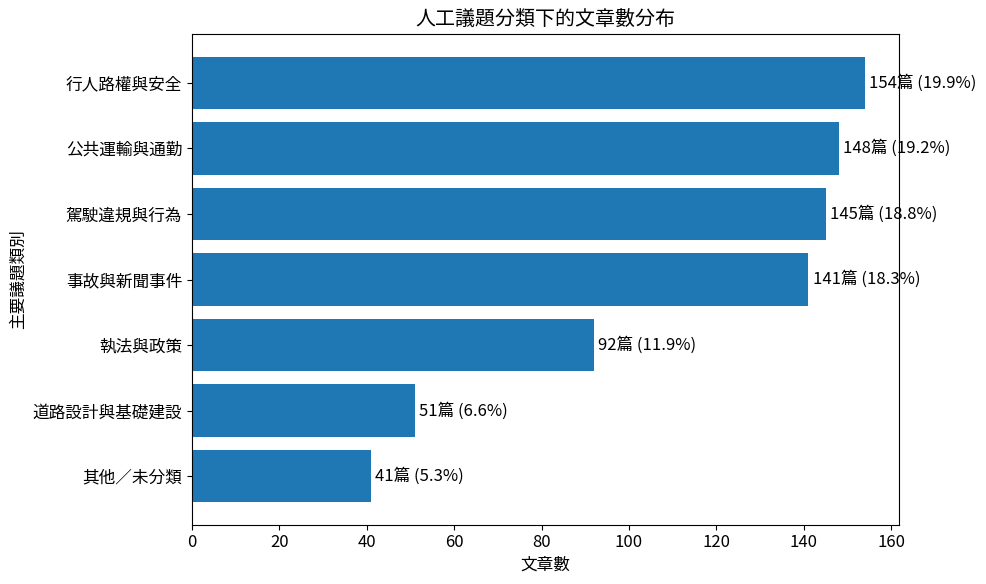

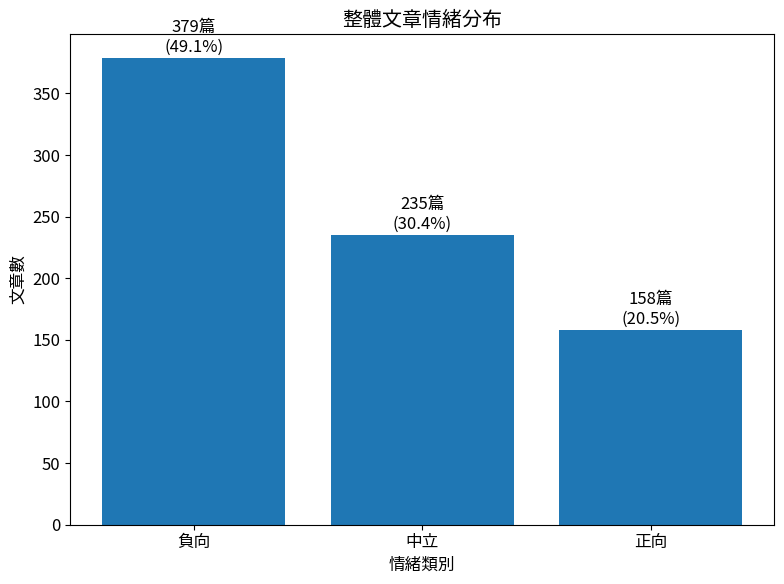

,main_topic,article_count,percentage
0,行人路權與安全,154,19.948187
1,公共運輸與通勤,148,19.170984
2,駕駛違規與行為,145,18.782383
3,事故與新聞事件,141,18.264249
4,執法與政策,92,11.917098
5,道路設計與基礎建設,51,6.606218
6,其他／未分類,41,5.310881


,sentiment_label,article_count,percentage
0,負向,379,49.093264
1,中立,235,30.440415
2,正向,158,20.466321


In [27]:
topic_counts = (
    df["main_topic_revised"]
    .value_counts()
    .rename_axis("main_topic")
    .reset_index(name="article_count")
)

topic_counts["percentage"] = topic_counts["article_count"] / topic_counts["article_count"].sum() * 100

plt.figure(figsize=(10, 6))
plt.barh(topic_counts["main_topic"], topic_counts["article_count"])
plt.gca().invert_yaxis()
plt.xlabel("文章數")
plt.ylabel("主要議題類別")
plt.title("人工議題分類下的文章數分布")

for i, row in topic_counts.iterrows():
    plt.text(row["article_count"] + 1, i, f'{row["article_count"]}篇 ({row["percentage"]:.1f}%)', va="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_basic_topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

sentiment_counts = (
    df["sentiment_label"]
    .value_counts()
    .reindex(["負向", "中立", "正向"])
    .fillna(0)
    .astype(int)
    .rename_axis("sentiment_label")
    .reset_index(name="article_count")
)

sentiment_counts["percentage"] = sentiment_counts["article_count"] / sentiment_counts["article_count"].sum() * 100

plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts["sentiment_label"], sentiment_counts["article_count"])
plt.xlabel("情緒類別")
plt.ylabel("文章數")
plt.title("整體文章情緒分布")

for i, row in sentiment_counts.iterrows():
    plt.text(i, row["article_count"] + 5, f'{row["article_count"]}篇\n({row["percentage"]:.1f}%)', ha="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_basic_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display(topic_counts)
display(sentiment_counts)

### 分析說明

基本分布圖顯示，本資料集中交通安全討論並非集中在單一面向，而是分散在行人路權、公共運輸、駕駛違規、事故新聞、政策執法與道路設計等不同類別。整體情緒則偏向負向，代表 PTT 使用者在討論交通安全與行人路權時，常伴隨批評、不滿或事故相關負面描述。這些結果會作為後續 LDA 與 BERTopic 主題模型的比較基準。

## D3. 方法一：LDA 主題模型

本儲存格使用 LDA 主題模型分析 PTT 交通安全文章。前面 C 階段的 main_topic_revised 是依據人工設計的議題字典分類，而 LDA 屬於無監督式主題模型，可以不依賴人工標籤，直接從文章詞彙中找出潛在主題。因此，執行 LDA 的目的，是檢查模型自動產生的主題是否能對應到交通安全討論中的主要面向，也可以觀察人工分類是否具有合理性。

LDA 修正版可用文件數： 772
LDA 字典詞彙數： 2579
LDA 語料文件數： 772


,topic_num,coherence_c_v,perplexity
0,3,0.356980,1514.542963
1,4,0.408034,1442.299470
2,5,0.418358,1422.403176
3,6,0.408228,1440.950522
4,7,0.408516,1431.858860
5,8,0.392205,1457.677948


修正版 LDA 選擇的主題數： 5


,lda_topic,rank,word,weight
0,0,1,汽車,0.021111
1,0,2,測速,0.017906
2,0,3,交通,0.011630
3,0,4,公里,0.007367
4,0,5,安全,0.006998
5,0,6,行人,0.006437
6,0,7,市場,0.005229
7,0,8,政府,0.005104
8,0,9,照相,0.005041
9,0,10,交通事故,0.004583


,lda_topic,article_count
0,0,104
1,1,221
2,2,129
3,3,192
4,4,126


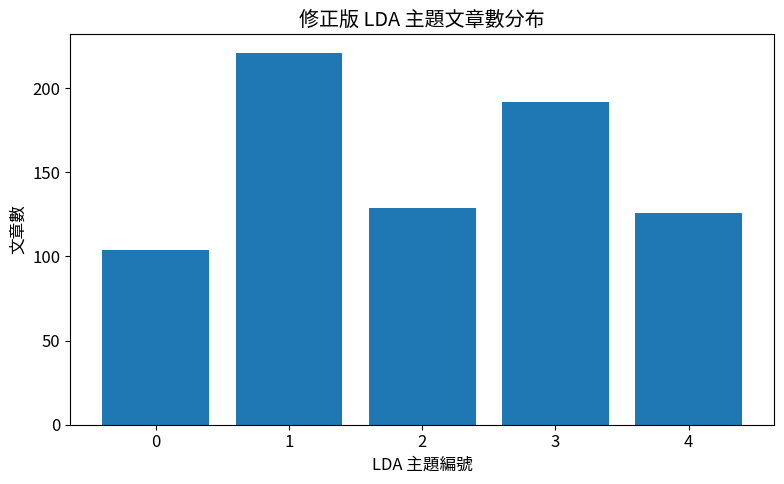

修正版 LDA 結果已儲存完成


In [28]:
# =========================
# D3 修正版：LDA 主題模型
# 排除國家詞、地名、新聞格式詞與泛用詞
# =========================

from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# LDA 專用停用詞
lda_extra_stopwords = set([
    # 國家與泛地理詞：避免主題被國際比較或地名帶走
    "中國", "美國", "日本", "韓國", "歐洲", "國外", "外國",
    "台灣", "台北", "高雄", "台中", "台南", "桃園", "屏東",
    "新北", "基隆", "新竹", "苗栗", "彰化", "雲林", "嘉義",
    "南投", "宜蘭", "花蓮", "台東", "澎湖",

    # 新聞格式詞
    "表示", "指出", "報導", "完整", "新聞", "媒體", "記者",
    "來源", "標題", "內文", "備註", "發生", "今天", "昨日",
    "上午", "下午", "晚間", "目前", "指出", "強調", "說明",

    # PTT 與泛用詞
    "Re", "Fw", "問卦", "八卦", "文章", "大家", "有人",
    "真的", "現在", "覺得", "知道", "可以", "沒有", "不是",
    "就是", "如果", "因為", "所以", "但是", "應該", "問題",
    "這個", "那個", "什麼", "怎麼", "一堆", "直接", "其實",
    "可能", "相關", "部分", "進行", "以及", "其中", "包括",
    "另外", "針對", "使用", "需要", "方式",

    # 數字與年份
    "2026", "2025", "2024", "2023", "114", "117", "118",
    "01", "02", "03", "04", "05", "06", "07", "08", "09",
    "10", "11", "12", "13", "14", "15", "16", "17", "18",
    "20", "23", "30", "50", "100"
])

# 保留交通安全核心詞
lda_keep_words = set([
    "交通", "安全", "行人", "機車", "汽車", "車禍", "事故",
    "酒駕", "毒駕", "違停", "違規", "測速", "警察", "警方",
    "交通部", "公車", "捷運", "人行道", "斑馬線", "庇護島",
    "車道", "路口", "駕駛", "執法", "罰單", "死亡", "受傷",
    "賠償", "自駕", "大橋", "號誌", "道路", "通勤", "公車",
    "左轉", "右轉", "超速", "肇事", "追撞", "擦撞"
])

# 建立 LDA 專用 tokens
docs_tokens_lda = []

for text in df["token_text"].fillna("").astype(str):
    words = []

    for w in text.split():
        w = w.strip()

        if not w:
            continue

        if w in lda_extra_stopwords:
            continue

        if w.isdigit():
            continue

        if len(w) < 2 and w not in lda_keep_words:
            continue

        words.append(w)

    if len(words) > 0:
        docs_tokens_lda.append(words)

print("LDA 修正版可用文件數：", len(docs_tokens_lda))

# 建立 LDA 字典與語料
lda_dictionary = Dictionary(docs_tokens_lda)
lda_dictionary.filter_extremes(no_below=5, no_above=0.6)

lda_corpus = [lda_dictionary.doc2bow(doc) for doc in docs_tokens_lda]

print("LDA 字典詞彙數：", len(lda_dictionary))
print("LDA 語料文件數：", len(lda_corpus))

# 比較不同主題數
topic_num_list = range(3, 9)
lda_eval_rows = []
lda_models = {}

for topic_num in topic_num_list:
    model = LdaModel(
        corpus=lda_corpus,
        id2word=lda_dictionary,
        num_topics=topic_num,
        random_state=2026,
        passes=10,
        iterations=100
    )

    coherence = CoherenceModel(
        model=model,
        texts=docs_tokens_lda,
        dictionary=lda_dictionary,
        coherence="c_v"
    ).get_coherence()

    perplexity = np.exp(-model.log_perplexity(lda_corpus))

    lda_eval_rows.append({
        "topic_num": topic_num,
        "coherence_c_v": coherence,
        "perplexity": perplexity
    })

    lda_models[topic_num] = model

lda_eval_revised = pd.DataFrame(lda_eval_rows)
display(lda_eval_revised)

best_topic_num = int(
    lda_eval_revised.sort_values("coherence_c_v", ascending=False).iloc[0]["topic_num"]
)

best_lda_model = lda_models[best_topic_num]

print("修正版 LDA 選擇的主題數：", best_topic_num)

# 輸出每個主題代表詞
lda_topic_words_revised = []

for topic_id in range(best_topic_num):
    words = best_lda_model.show_topic(topic_id, topn=12)

    for rank, (word, weight) in enumerate(words, start=1):
        lda_topic_words_revised.append({
            "lda_topic": topic_id,
            "rank": rank,
            "word": word,
            "weight": weight
        })

lda_topic_words_revised = pd.DataFrame(lda_topic_words_revised)
display(lda_topic_words_revised)

# 每篇文章最主要的 LDA topic
doc_topic_rows = []

for i, bow in enumerate(lda_corpus):
    topic_dist = best_lda_model.get_document_topics(bow)

    if len(topic_dist) == 0:
        main_topic = None
        main_prob = 0
    else:
        main_topic, main_prob = max(topic_dist, key=lambda x: x[1])

    doc_topic_rows.append({
        "doc_index_for_lda": i,
        "lda_main_topic": main_topic,
        "lda_topic_prob": main_prob
    })

lda_doc_topic_revised = pd.DataFrame(doc_topic_rows)

lda_topic_distribution_revised = (
    lda_doc_topic_revised["lda_main_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("lda_topic")
    .reset_index(name="article_count")
)

display(lda_topic_distribution_revised)

plt.figure(figsize=(8, 5))
plt.bar(
    lda_topic_distribution_revised["lda_topic"].astype(str),
    lda_topic_distribution_revised["article_count"]
)
plt.xlabel("LDA 主題編號")
plt.ylabel("文章數")
plt.title("修正版 LDA 主題文章數分布")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_LDA_topic_distribution_revised.png", dpi=300, bbox_inches="tight")
plt.show()

# 儲存結果
lda_eval_revised.to_csv(
    ADV_OUTPUT_DIR / "D_LDA_model_evaluation_revised.csv",
    index=False,
    encoding="utf-8-sig"
)

lda_topic_words_revised.to_csv(
    ADV_OUTPUT_DIR / "D_LDA_topic_words_revised.csv",
    index=False,
    encoding="utf-8-sig"
)

lda_doc_topic_revised.to_csv(
    ADV_OUTPUT_DIR / "D_LDA_document_topics_revised.csv",
    index=False,
    encoding="utf-8-sig"
)

print("修正版 LDA 結果已儲存完成")

In [31]:
# =========================
# 建立可與人工議題比較的修正版 LDA 資料表
# =========================

lda_used_rows = []

for idx, text in enumerate(df["token_text"].fillna("").astype(str)):
    words = []

    for w in text.split():
        w = w.strip()

        if not w:
            continue

        if w in lda_extra_stopwords:
            continue

        if w.isdigit():
            continue

        if len(w) < 2 and w not in lda_keep_words:
            continue

        words.append(w)

    if len(words) > 0:
        lda_used_rows.append(idx)

df_lda_base_revised = df.loc[lda_used_rows].reset_index(drop=True).copy()
df_lda_base_revised = pd.concat([df_lda_base_revised, lda_doc_topic_revised], axis=1)

df_lda_base_revised.to_csv(
    ADV_OUTPUT_DIR / "D_LDA_document_topics_revised_with_text.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    df_lda_base_revised[
        ["title", "main_topic_revised", "lda_main_topic", "lda_topic_prob"]
    ].head()
)

print("df_lda_base_revised 已建立完成")

,title,main_topic_revised,lda_main_topic,lda_topic_prob
0,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,其他／未分類,0,0.610471
1,[新聞] 李多慧化身「交通安全宣導女神」 警局男,駕駛違規與行為,4,0.737264
2,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,行人路權與安全,2,0.922259
3,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,行人路權與安全,2,0.369987
4,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,行人路權與安全,1,0.924542


df_lda_base_revised 已建立完成


### LDA 分析說明

LDA 結果可以作為人工字典分類的補充。若某些 LDA 主題的代表詞集中在「行人、人行道、斑馬線」，可以解釋為行人路權主題；若代表詞集中在「酒駕、違停、警察、罰單」，則可以解釋為違規與執法主題。由於 LDA 不依賴人工標籤，因此它可以檢查原本分類是否合理，也可能發現字典分類沒有明確區分出的潛在討論面向。

## D4. LDA 與人工議題分類的交叉比較

本儲存格的目的，是比較 LDA 自動產生的主題與本研究人工設計的議題類別是否一致。若某個 LDA 主題主要集中在某一個人工議題中，代表該人工分類具有語意一致性；若同一個 LDA 主題分散在多個人工議題中，則代表交通安全討論本身可能具有跨議題特性。

lda_main_topic,0,1,2,3,4
main_topic_revised,,,,,
事故與新聞事件,23,22,11,16,69
公共運輸與通勤,11,61,57,16,3
其他／未分類,20,10,6,4,1
執法與政策,34,21,10,22,5
行人路權與安全,12,32,35,58,17
道路設計與基礎建設,1,9,4,28,9
駕駛違規與行為,3,66,6,48,22


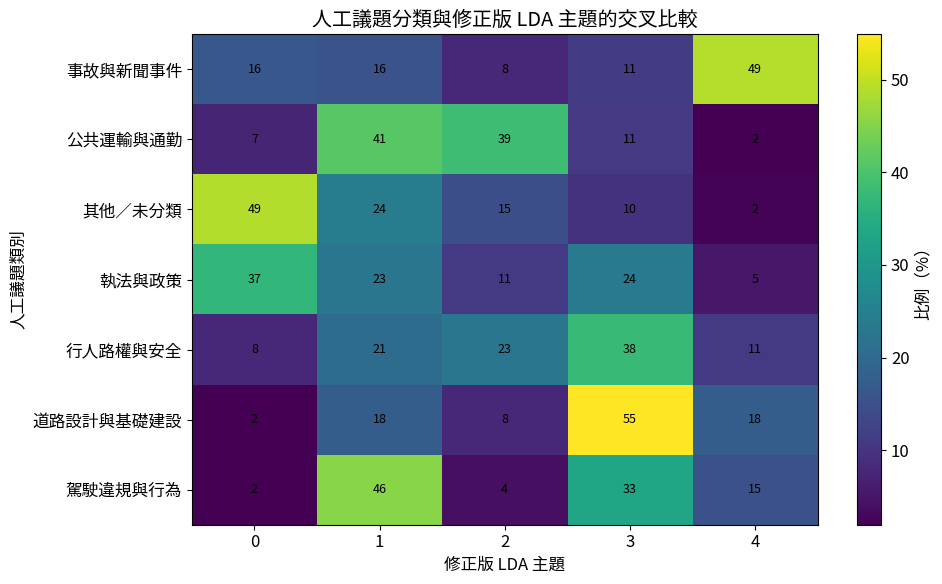

修正版 LDA 交叉比較已完成


In [32]:


import pandas as pd
import matplotlib.pyplot as plt

# 如果 df_lda_base_revised 不存在，就從修正版 LDA 輸出檔讀回來
if "df_lda_base_revised" not in globals():
    revised_lda_path = ADV_OUTPUT_DIR / "D_LDA_document_topics_revised_with_text.csv"

    if revised_lda_path.exists():
        df_lda_base_revised = pd.read_csv(revised_lda_path)
    else:
        raise NameError(
            "找不到 df_lda_base_revised，也找不到 D_LDA_document_topics_revised_with_text.csv。"
            "請先確認修正版 LDA 那格是否有完整跑完。"
        )

lda_cross_revised = pd.crosstab(
    df_lda_base_revised["main_topic_revised"],
    df_lda_base_revised["lda_main_topic"]
)

display(lda_cross_revised)

lda_cross_ratio_revised = lda_cross_revised.div(
    lda_cross_revised.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(10, 6))
plt.imshow(lda_cross_ratio_revised, aspect="auto")

plt.xticks(
    range(lda_cross_ratio_revised.shape[1]),
    lda_cross_ratio_revised.columns
)

plt.yticks(
    range(lda_cross_ratio_revised.shape[0]),
    lda_cross_ratio_revised.index
)

plt.colorbar(label="比例（%）")
plt.xlabel("修正版 LDA 主題")
plt.ylabel("人工議題類別")
plt.title("人工議題分類與修正版 LDA 主題的交叉比較")

for i in range(lda_cross_ratio_revised.shape[0]):
    for j in range(lda_cross_ratio_revised.shape[1]):
        value = lda_cross_ratio_revised.iloc[i, j]
        if value > 0:
            plt.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=9
            )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "D_LDA_cross_manual_topic_heatmap_revised.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

lda_cross_revised.to_csv(
    ADV_OUTPUT_DIR / "D_LDA_cross_manual_topic_revised.csv",
    encoding="utf-8-sig"
)

print("修正版 LDA 交叉比較已完成")

## D3-1 LDA Intertopic Distance Map

本儲存格的目的是將 LDA 主題模型結果視覺化成 Intertopic Distance Map。前一個儲存格已經透過 LDA 找出文章中的潛在主題，但只看主題代表詞較難判斷不同主題之間是否相近或重疊。因此，本研究使用 pyLDAvis 產生主題距離圖，觀察不同 LDA 主題在語意空間中的相對位置。若主題圓圈彼此距離較遠，代表主題差異較明顯；若主題圓圈重疊或接近，則表示交通安全文章中的主題可能具有交疊性。

In [48]:

import pyLDAvis
import pyLDAvis.gensim_models
from IPython.display import display, HTML

# 確認修正版 LDA 已經跑完
required_vars = ["best_lda_model", "lda_corpus", "lda_dictionary"]

for var in required_vars:
    if var not in globals():
        raise NameError(
            f"找不到 {var}。請先執行 D3 修正版 LDA 主題模型，再執行本儲存格。"
        )

# 啟用 notebook 顯示
pyLDAvis.enable_notebook()

# 建立 LDA 視覺化物件
lda_vis = pyLDAvis.gensim_models.prepare(
    best_lda_model,
    lda_corpus,
    lda_dictionary,
    sort_topics=False
)


display(lda_vis)

# 儲存成 HTML，方便繳交或放進報告資料夾
lda_vis_path = ADV_OUTPUT_DIR / "D_LDA_intertopic_distance_map_revised.html"

pyLDAvis.save_html(
    lda_vis,
    str(lda_vis_path)
)

print("LDA Intertopic Distance Map 已輸出：")
print(lda_vis_path)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.061473 -0.149693       1        1  17.023549
1      0.102909  0.050918       2        1  18.792442
2     -0.006208 -0.013071       3        1  15.085358
3      0.036360  0.111043       4        1  23.405462
4     -0.194534  0.000805       5        1  25.693189, topic_info=     Term        Freq       Total Category  logprob  loglift
210    公車  332.000000  332.000000  Default  30.0000  30.0000
1853   捷運  302.000000  302.000000  Default  29.0000  29.0000
748    車道  397.000000  397.000000  Default  28.0000  28.0000
73     酒駕  388.000000  388.000000  Default  27.0000  27.0000
1017   違停  320.000000  320.000000  Default  26.0000  26.0000
...   ...         ...         ...      ...      ...      ...
146    發現   75.482096  169.917913   Topic5  -5.2821   0.5475
1539   賠償   57.508369  102.751572   Topic5  -5.5540   0.7786
71     違規   57.312436  171.463126   Topic5  -5.5574   0.2631
748    車道   62.873584  397.844238   Topic5  -5.4648  -0.4860
37     安全   58.540681  252.562637   Topic5  -5.5362  -0.1030

[366 rows x 6 columns], token_table=      Topic      Freq Term
term                      
367       1  0.153034   AI
367       2  0.703954   AI
367       3  0.030607   AI
367       4  0.107123   AI
367       5  0.015303   AI
...     ...       ...  ...
754       5  0.946399   骨折
2519      3  0.859198   高架
2519      4  0.061371   高架
2519      5  0.061371   高架
2480      3  0.968822   高鐵

[801 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

LDA Intertopic Distance Map 已輸出：
/content/ptt_traffic_safety_project/outputs/advanced_methods/D_LDA_intertopic_distance_map_revised.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## D5. 方法二：BERTopic 主題模型

本儲存格使用 BERTopic 分析文章主題。LDA 是以詞袋模型為基礎，較容易受到斷詞與詞頻影響；而 BERTopic 會先將文章轉換成 BERT 語意向量，再根據語意相似度進行主題分群。因此本研究使用 BERTopic 作為 LDA 的補充，觀察在語意層面上，PTT 交通安全文章是否會形成不同主題群。

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

2026-06-22 18:36:35,949 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-22 18:36:47,580 - BERTopic - Dimensionality - Completed ✓
2026-06-22 18:36:47,582 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-22 18:36:47,628 - BERTopic - Cluster - Completed ✓
2026-06-22 18:36:47,631 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-22 18:36:49,171 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,173,0_酒駕_違停_警察_民進,"[酒駕, 違停, 警察, 民進, 03, 如果, 自己, 05, 一個, 不是, 看到, 所以]",[點名徐嶔煌曾酒駕選議員沒事 賴苡任 新 1 新聞網址 2 新聞來源 聯合報 3 點名徐嶔煌...
1,1,171,1_機車_汽車_車道_中國,"[機車, 汽車, 車道, 中國, 左轉, 美國, 淡江, 問題, 大橋, 直接, 人行道, 市場]",[淡江大橋機車道過窄惹議 高屏大橋拓寬機 淡江大橋機車道過窄惹議 高屏大橋拓寬機車道成雙線有...
2,2,133,2_警方_發生_車禍_事故,"[警方, 發生, 車禍, 事故, 駕駛, 現場, 機車, 男子, 安全, 報導, 表示, 車道]",[行人地獄 台中男轉彎 撞飛 女高中生 1 nownews 2 鄧庭婷 3 行人地獄 台中男...
3,3,106,3_測速_照相_交通_行人,"[測速, 照相, 交通, 行人, 斑馬線, 人行道, 庇護島, 安全, 路段, 路口, 設置...",[測速照相空桿 恐嚇民眾還搶錢 1 轉錄網址 2 轉錄來源 中國時報投書 測速照相空桿 恐嚇...
4,4,106,4_公車_捷運_無人_自駕,"[公車, 捷運, 無人, 自駕, 沈伯洋, 預算, 司機, 藍線, 台北市, 高鐵, 台北,...",[北市規劃推動無人自駕公車 禁紅色供應鏈 1 中央社 2 楊淑閔 3 北市規劃推動無人自駕公...
5,5,83,5_賠償_交通_車禍_行人,"[賠償, 交通, 車禍, 行人, 日本, 人行道, 06, 交通事故, 問題, 死亡, 不是...",[真正行人地獄 不是台北台中 研究揭全台4縣市交通風險最 真正行人地獄 不是台北台中 研究揭...


,bertopic_topic,rank,word,weight
0,0,1,酒駕,0.074997
1,0,2,違停,0.045244
2,0,3,警察,0.033183
3,0,4,民進,0.025684
4,0,5,03,0.024160
5,0,6,如果,0.024063
6,0,7,自己,0.023395
7,0,8,05,0.022256
8,0,9,一個,0.021812
9,0,10,不是,0.021088


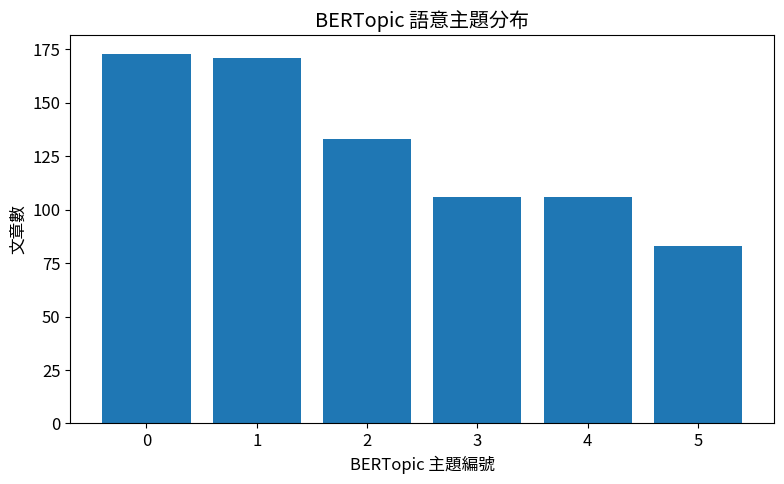

In [33]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
import jieba

# 為了控制 Colab 時間，必要時可調整樣本數；773 筆通常可以全跑
MAX_BERTOPIC_DOCS = min(len(df), 773)

df_bertopic = df.copy().reset_index(drop=True).iloc[:MAX_BERTOPIC_DOCS].copy()

docs_for_bertopic = df_bertopic["clean_text"].fillna("").astype(str).tolist()

# 加入交通安全專案常見詞，讓中文分詞較穩定
custom_words = [
    "行人地獄", "交通安全", "行人路權", "人行道", "斑馬線",
    "酒駕", "違停", "科技執法", "公共運輸", "交通事故",
    "道路設計", "大眾運輸", "交通部"
]

for w in custom_words:
    jieba.add_word(w)

stopwords_bertopic = list(set([
    "的", "了", "是", "在", "我", "有", "和", "就", "不", "都", "也",
    "很", "到", "說", "要", "去", "會", "可以", "沒有", "就是",
    "這個", "那個", "什麼", "怎麼", "台灣", "大家", "新聞",
    "記者", "媒體", "來源", "完整", "標題", "內文"
]))

def tokenize_for_bertopic(text):
    return [
        w for w in jieba.lcut(text)
        if len(w.strip()) >= 2 and w.strip() not in stopwords_bertopic
    ]

# 使用多語句向量模型，較適合中文與社群短文
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = embedding_model.encode(
    docs_for_bertopic,
    show_progress_bar=True,
    batch_size=32
)

# 使用 KMeans 讓主題數較穩定，也方便和人工六類比較
cluster_model = KMeans(n_clusters=6, random_state=2026)

vectorizer_model = CountVectorizer(
    tokenizer=tokenize_for_bertopic,
    token_pattern=None,
    min_df=3
)

bertopic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    top_n_words=12,
    verbose=True
)

bertopic_topics, bertopic_probs = bertopic_model.fit_transform(docs_for_bertopic, embeddings)

df_bertopic["bertopic_topic"] = bertopic_topics

bertopic_info = bertopic_model.get_topic_info()
display(bertopic_info)

bertopic_topic_words = []

for topic_id in sorted(df_bertopic["bertopic_topic"].unique()):
    topic_words = bertopic_model.get_topic(topic_id)
    if topic_words is None:
        continue

    for rank, (word, weight) in enumerate(topic_words, start=1):
        bertopic_topic_words.append({
            "bertopic_topic": topic_id,
            "rank": rank,
            "word": word,
            "weight": weight
        })

bertopic_topic_words = pd.DataFrame(bertopic_topic_words)
display(bertopic_topic_words.head(30))

bertopic_counts = (
    df_bertopic["bertopic_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("bertopic_topic")
    .reset_index(name="article_count")
)

plt.figure(figsize=(8, 5))
plt.bar(bertopic_counts["bertopic_topic"].astype(str), bertopic_counts["article_count"])
plt.xlabel("BERTopic 主題編號")
plt.ylabel("文章數")
plt.title("BERTopic 語意主題分布")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_BERTopic_topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

bertopic_info.to_csv(ADV_OUTPUT_DIR / "D_BERTopic_topic_info.csv", index=False, encoding="utf-8-sig")
bertopic_topic_words.to_csv(ADV_OUTPUT_DIR / "D_BERTopic_topic_words.csv", index=False, encoding="utf-8-sig")
df_bertopic.to_csv(ADV_OUTPUT_DIR / "D_BERTopic_document_topics.csv", index=False, encoding="utf-8-sig")

### BERTopic 分析說明

BERTopic 的結果可以用來觀察文章在語意層面上的主題分群。相較於 LDA，BERTopic 不只依賴詞頻，而是先將文章轉換為語意向量，因此較能處理「用詞不同但意思相近」的文章。若 BERTopic 的某些主題代表詞與 LDA 或人工分類相似，代表交通安全討論的主題結構較穩定；若 BERTopic 產生不同主題，則可能代表 PTT 上存在字典分類未捕捉到的語意群。

In [49]:
from IPython.display import display

if "bertopic_model" not in globals():
    raise NameError("找不到 bertopic_model。請先執行 D5 BERTopic 主題模型。")

# BERTopic 的 topic map，概念上類似主題距離視覺化
fig_bertopic_topics = bertopic_model.visualize_topics()

display(fig_bertopic_topics)

# 儲存成 HTML
bertopic_topic_map_path = ADV_OUTPUT_DIR / "D_BERTopic_topic_map.html"
fig_bertopic_topics.write_html(str(bertopic_topic_map_path))

print("BERTopic Topic Map 已輸出：")
print(bertopic_topic_map_path)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



BERTopic Topic Map 已輸出：
/content/ptt_traffic_safety_project/outputs/advanced_methods/D_BERTopic_topic_map.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

## D6. BERTopic 與人工議題分類比較

本儲存格的目的，是比較 BERTopic 語意分群與人工議題分類的關係。人工分類是根據關鍵字字典判斷，而 BERTopic 是根據 BERT 語意向量分群。透過交叉表可以觀察兩種方法是否產生相近結果，也可以找出哪些人工議題在語意上其實會和其他議題混在一起。

bertopic_topic,0,1,2,3,4,5
main_topic_revised,,,,,,
事故與新聞事件,11,33,59,8,1,29
公共運輸與通勤,25,10,9,6,96,2
其他／未分類,1,31,4,1,1,3
執法與政策,24,22,4,39,1,2
行人路權與安全,25,32,27,32,3,35
道路設計與基礎建設,0,33,7,8,2,1
駕駛違規與行為,87,10,23,12,2,11


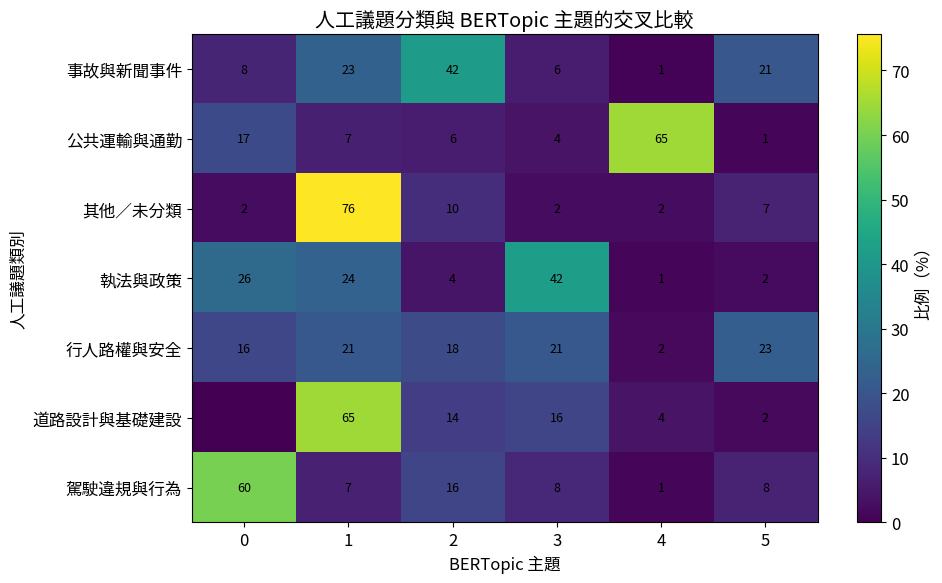

In [34]:
bertopic_cross = pd.crosstab(
    df_bertopic["main_topic_revised"],
    df_bertopic["bertopic_topic"]
)

display(bertopic_cross)

bertopic_cross_ratio = bertopic_cross.div(bertopic_cross.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
plt.imshow(bertopic_cross_ratio, aspect="auto")
plt.xticks(range(bertopic_cross_ratio.shape[1]), bertopic_cross_ratio.columns)
plt.yticks(range(bertopic_cross_ratio.shape[0]), bertopic_cross_ratio.index)
plt.colorbar(label="比例（%）")
plt.xlabel("BERTopic 主題")
plt.ylabel("人工議題類別")
plt.title("人工議題分類與 BERTopic 主題的交叉比較")

for i in range(bertopic_cross_ratio.shape[0]):
    for j in range(bertopic_cross_ratio.shape[1]):
        value = bertopic_cross_ratio.iloc[i, j]
        if value > 0:
            plt.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_BERTopic_cross_manual_topic_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

bertopic_cross.to_csv(ADV_OUTPUT_DIR / "D_BERTopic_cross_manual_topic.csv", encoding="utf-8-sig")

## D7. 方法三：共詞網路圖 Co-word Network

本儲存格的目的，是將文字資料轉換成圖形資料。前面的 LDA 和 BERTopic 關注主題分群，但共詞網路可以觀察哪些詞彙經常在同一篇文章中一起出現。本研究將詞彙視為節點，若兩個詞在同一篇文章中共同出現，就建立一條邊。透過 degree centrality 與 betweenness centrality，可以找出交通安全討論中的核心詞與橋接詞。

保留節點數： 40
['機車', '車道', '行人', '酒駕', '交通', '車禍', '汽車', '公車', '違停', '捷運', '人行道', '發生', '事故', '安全', '駕駛', '警方', '測速', '車輛', '政府', '中國', '違規', '發現', '淡江', '路口', '地方', '造成', '警察', '美國', '改善', '斑馬線', '現場', '左轉', '台北', '大橋', '我們', '台北市', '道路', '高雄', '男子', '這種']
初始節點數： 40
初始邊數： 288
稀疏化後節點數： 38
稀疏化後邊數： 119


,word,frequency,degree_centrality,betweenness_centrality
4,交通,387,0.567568,0.330831
11,發生,276,0.405405,0.010511
0,機車,546,0.378378,0.078829
15,警方,257,0.351351,0.077077
13,安全,262,0.324324,0.056306
1,車道,415,0.243243,0.015766
5,車禍,379,0.243243,0.028278
14,駕駛,258,0.243243,0.048799
18,政府,189,0.216216,0.070571
17,車輛,209,0.216216,0.043544


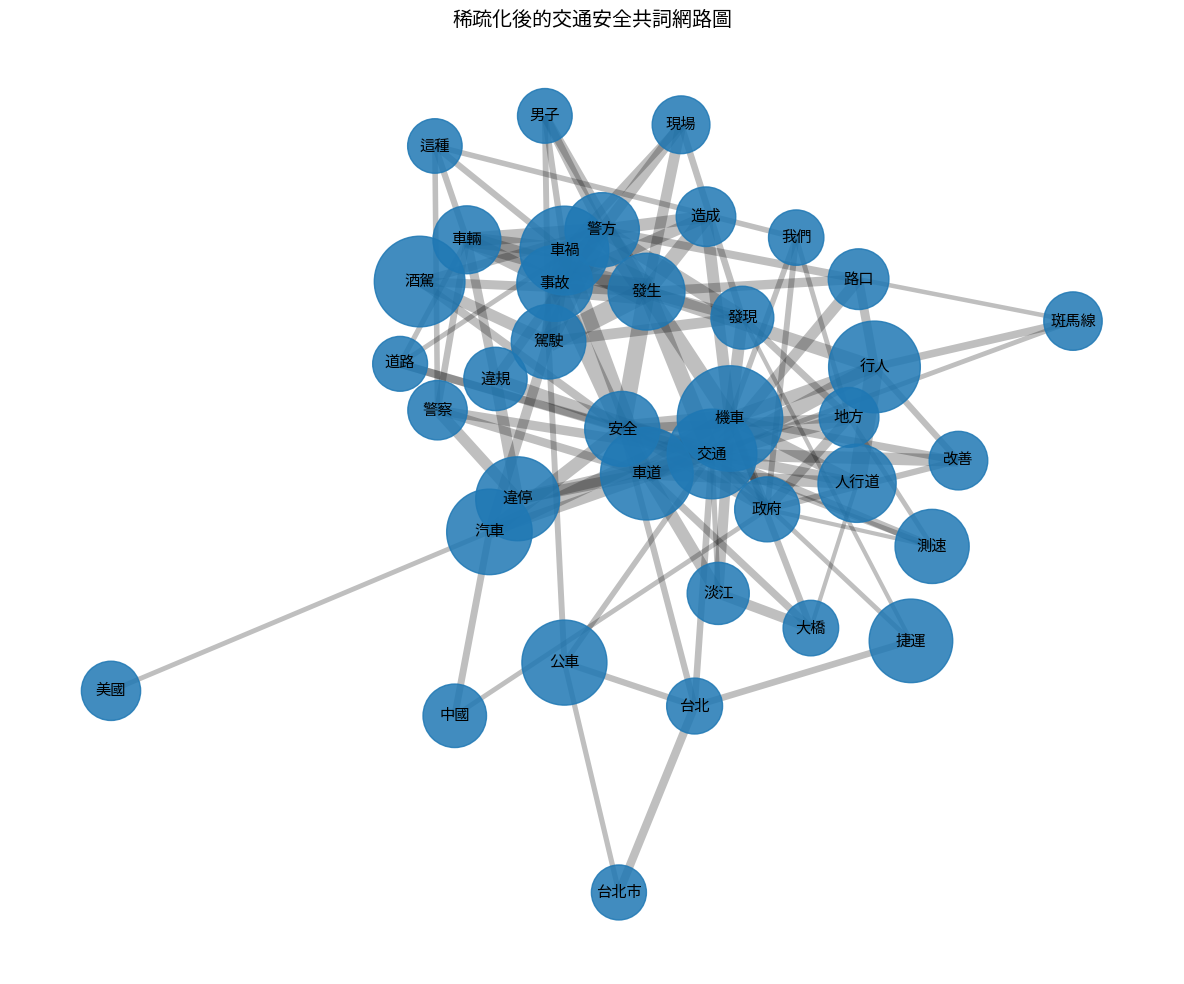

/content/ptt_traffic_safety_project/outputs/advanced_methods/D_Coword_network_sparse_interactive.html
稀疏化互動式共詞網路圖已輸出：
/content/ptt_traffic_safety_project/outputs/advanced_methods/D_Coword_network_sparse_interactive.html


In [52]:


import re
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from itertools import combinations
from pyvis.network import Network
from IPython.display import HTML

# -------------------------
# 1. 停用詞設定
# -------------------------

extra_stopwords_network = set([
    "表示", "指出", "報導", "完整", "新聞", "媒體", "記者", "來源",
    "標題", "內文", "備註", "時間", "更新", "發佈", "責任", "編輯",
    "Re", "Fw", "問卦", "八卦", "文章", "網址", "回覆",
    "台灣", "問題", "真的", "現在", "知道", "看到", "直接", "覺得",
    "自己", "大家", "有人", "如果", "因為", "所以", "但是", "應該",
    "可以", "沒有", "不是", "還是", "這樣", "一堆", "就是", "什麼",
    "怎麼", "可能", "相關", "部分", "進行", "以及", "其中", "包括",
    "另外", "針對", "使用", "需要", "方式", "比較", "很多", "不能",
    "不會", "不要", "不用", "已經", "這些", "那些", "一樣",
    "今天", "昨天", "明天", "去年", "今年", "目前", "上午", "下午",
    "晚上", "2026", "2025", "2024", "2023", "114", "117", "118"
])

domain_keep_words = set([
    "行人", "機車", "汽車", "公車", "捷運", "車禍", "事故", "酒駕",
    "毒駕", "違停", "違規", "測速", "警察", "交通部", "人行道",
    "斑馬線", "庇護島", "路口", "車道", "駕駛", "安全", "執法",
    "罰單", "賠償", "死亡", "受傷", "左轉", "右轉", "自駕", "大橋",
    "道路", "通勤", "號誌", "超速", "肇事", "追撞", "擦撞"
])

# -------------------------
# 2. 建立乾淨 tokens
# -------------------------

clean_docs_tokens = []

for text in df["token_text"].fillna("").astype(str):
    words = []

    for w in text.split():
        w = w.strip()

        if not w:
            continue

        if re.fullmatch(r"\d+", w):
            continue

        if w in extra_stopwords_network:
            continue

        if len(w) < 2 and w not in domain_keep_words:
            continue

        words.append(w)

    clean_docs_tokens.append(words)

# -------------------------
# 3. 只取 Top 40 詞作為節點
# -------------------------

all_tokens = []
for words in clean_docs_tokens:
    all_tokens.extend(words)

token_freq = Counter(all_tokens)

TOP_N_TERMS = 40

top_terms = [
    word for word, count in token_freq.most_common(TOP_N_TERMS)
    if count >= 8
]

top_terms_set = set(top_terms)

print("保留節點數：", len(top_terms))
print(top_terms)

# -------------------------
# 4. 每篇文章最多只取前 10 個詞建立共現
# -------------------------

MAX_WORDS_PER_DOC = 10
edge_counter = Counter()

for words in clean_docs_tokens:
    filtered_words = [w for w in words if w in top_terms_set]

    # 按整體詞頻排序，每篇文章只取前 10 個較重要詞
    filtered_words = sorted(
        set(filtered_words),
        key=lambda x: token_freq[x],
        reverse=True
    )[:MAX_WORDS_PER_DOC]

    for w1, w2 in combinations(sorted(filtered_words), 2):
        edge_counter[(w1, w2)] += 1

# -------------------------
# 5. 先建立完整圖，再保留強邊
# -------------------------

G_full = nx.Graph()

for word in top_terms:
    G_full.add_node(word, frequency=token_freq[word])

MIN_CO_OCCUR = 12

for (w1, w2), weight in edge_counter.items():
    if weight >= MIN_CO_OCCUR:
        G_full.add_edge(w1, w2, weight=weight)

print("初始節點數：", G_full.number_of_nodes())
print("初始邊數：", G_full.number_of_edges())

# -------------------------
# 6. Backbone：每個節點只保留最強前 4 條邊
# -------------------------

MAX_EDGES_PER_NODE = 4

edges_to_keep = set()

for node in G_full.nodes():
    neighbors = []

    for neighbor in G_full.neighbors(node):
        weight = G_full[node][neighbor]["weight"]
        neighbors.append((node, neighbor, weight))

    neighbors = sorted(neighbors, key=lambda x: x[2], reverse=True)

    for u, v, w in neighbors[:MAX_EDGES_PER_NODE]:
        edges_to_keep.add(tuple(sorted([u, v])))

G = nx.Graph()

for node in G_full.nodes():
    G.add_node(node, frequency=G_full.nodes[node]["frequency"])

for u, v in edges_to_keep:
    if G_full.has_edge(u, v):
        G.add_edge(u, v, weight=G_full[u][v]["weight"])

# 移除孤立點
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

print("稀疏化後節點數：", G.number_of_nodes())
print("稀疏化後邊數：", G.number_of_edges())

# -------------------------
# 7. 計算中心性
# -------------------------

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight")

centrality_df_sparse = pd.DataFrame({
    "word": list(G.nodes()),
    "frequency": [G.nodes[n]["frequency"] for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()]
}).sort_values("degree_centrality", ascending=False)

display(centrality_df_sparse.head(20))

centrality_df_sparse.to_csv(
    ADV_OUTPUT_DIR / "D_Coword_network_centrality_sparse.csv",
    index=False,
    encoding="utf-8-sig"
)

# -------------------------
# 8. 畫靜態圖
# -------------------------

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    k=0.8,
    seed=2026,
    iterations=100
)

node_sizes = [
    300 + G.nodes[n]["frequency"] * 10
    for n in G.nodes()
]

edge_widths = [
    max(0.8, G[u][v]["weight"] / 4)
    for u, v in G.edges()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.25
)

nx.draw_networkx_labels(
    G,
    pos,
    font_family="Noto Sans CJK JP",
    font_size=11
)

plt.title("稀疏化後的交通安全共詞網路圖")
plt.axis("off")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "D_Coword_network_sparse.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -------------------------
# 9. 互動式圖
# -------------------------

net = Network(
    notebook=True,
    cdn_resources="in_line",
    height="700px",
    width="100%"
)

for node in G.nodes():
    net.add_node(
        node,
        label=node,
        value=G.nodes[node]["frequency"],
        title=(
            f"{node}<br>"
            f"詞頻：{G.nodes[node]['frequency']}<br>"
            f"Degree centrality：{degree_centrality[node]:.3f}<br>"
            f"Betweenness centrality：{betweenness_centrality[node]:.3f}"
        )
    )

for u, v, data in G.edges(data=True):
    net.add_edge(
        u,
        v,
        value=data["weight"],
        title=f"共現次數：{data['weight']}"
    )

network_html_path = ADV_OUTPUT_DIR / "D_Coword_network_sparse_interactive.html"
net.show(str(network_html_path))

print("稀疏化互動式共詞網路圖已輸出：")
print(network_html_path)

HTML(str(network_html_path))

指定議題： 行人路權與安全
文章數： 154
子網路節點數： 30
子網路邊數： 76


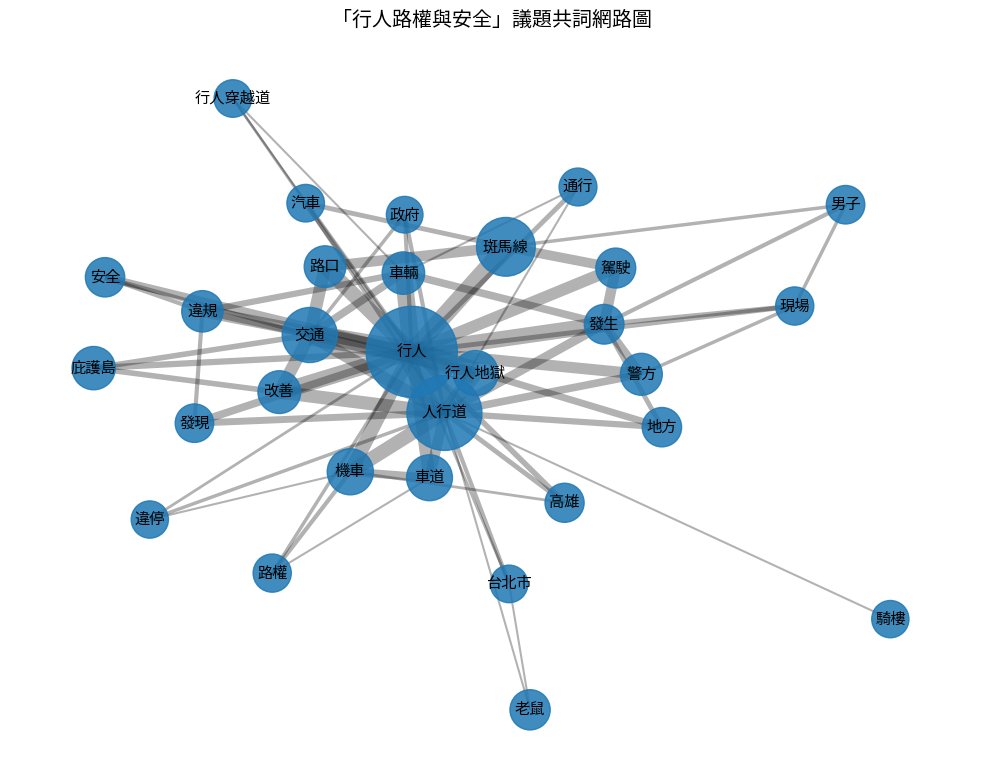

In [53]:

target_topic = "行人路權與安全"

df_topic_network = df[df["main_topic_revised"] == target_topic].copy()

print("指定議題：", target_topic)
print("文章數：", len(df_topic_network))

topic_docs_tokens = []

for text in df_topic_network["token_text"].fillna("").astype(str):
    words = []

    for w in text.split():
        w = w.strip()

        if not w:
            continue

        if re.fullmatch(r"\d+", w):
            continue

        if w in extra_stopwords_network:
            continue

        if len(w) < 2 and w not in domain_keep_words:
            continue

        words.append(w)

    topic_docs_tokens.append(words)

topic_all_tokens = []
for words in topic_docs_tokens:
    topic_all_tokens.extend(words)

topic_token_freq = Counter(topic_all_tokens)

TOP_N_TERMS_TOPIC = 30

topic_top_terms = [
    word for word, count in topic_token_freq.most_common(TOP_N_TERMS_TOPIC)
    if count >= 3
]

topic_top_terms_set = set(topic_top_terms)

topic_edge_counter = Counter()

for words in topic_docs_tokens:
    filtered_words = [w for w in words if w in topic_top_terms_set]

    filtered_words = sorted(
        set(filtered_words),
        key=lambda x: topic_token_freq[x],
        reverse=True
    )[:8]

    for w1, w2 in combinations(sorted(filtered_words), 2):
        topic_edge_counter[(w1, w2)] += 1

G_topic = nx.Graph()

for word in topic_top_terms:
    G_topic.add_node(word, frequency=topic_token_freq[word])

MIN_CO_OCCUR_TOPIC = 3

for (w1, w2), weight in topic_edge_counter.items():
    if weight >= MIN_CO_OCCUR_TOPIC:
        G_topic.add_edge(w1, w2, weight=weight)

# 每個節點保留前 3 條強邊
edges_to_keep = set()

for node in G_topic.nodes():
    neighbors = []

    for neighbor in G_topic.neighbors(node):
        weight = G_topic[node][neighbor]["weight"]
        neighbors.append((node, neighbor, weight))

    neighbors = sorted(neighbors, key=lambda x: x[2], reverse=True)

    for u, v, w in neighbors[:3]:
        edges_to_keep.add(tuple(sorted([u, v])))

G_topic_sparse = nx.Graph()

for node in G_topic.nodes():
    G_topic_sparse.add_node(node, frequency=G_topic.nodes[node]["frequency"])

for u, v in edges_to_keep:
    if G_topic.has_edge(u, v):
        G_topic_sparse.add_edge(u, v, weight=G_topic[u][v]["weight"])

G_topic_sparse.remove_nodes_from(list(nx.isolates(G_topic_sparse)))

print("子網路節點數：", G_topic_sparse.number_of_nodes())
print("子網路邊數：", G_topic_sparse.number_of_edges())

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    G_topic_sparse,
    k=0.9,
    seed=2026,
    iterations=100
)

node_sizes = [
    300 + G_topic_sparse.nodes[n]["frequency"] * 12
    for n in G_topic_sparse.nodes()
]

edge_widths = [
    max(0.8, G_topic_sparse[u][v]["weight"] / 2)
    for u, v in G_topic_sparse.edges()
]

nx.draw_networkx_nodes(
    G_topic_sparse,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G_topic_sparse,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_labels(
    G_topic_sparse,
    pos,
    font_family="Noto Sans CJK JP",
    font_size=11
)

plt.title(f"「{target_topic}」議題共詞網路圖")
plt.axis("off")
plt.tight_layout()

safe_topic_name = target_topic.replace("／", "_").replace("/", "_")
plt.savefig(
    FIGURE_DIR / f"D_Coword_network_topic_{safe_topic_name}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

指定議題： 事故與新聞事件
文章數： 141
子網路節點數： 29
子網路邊數： 70


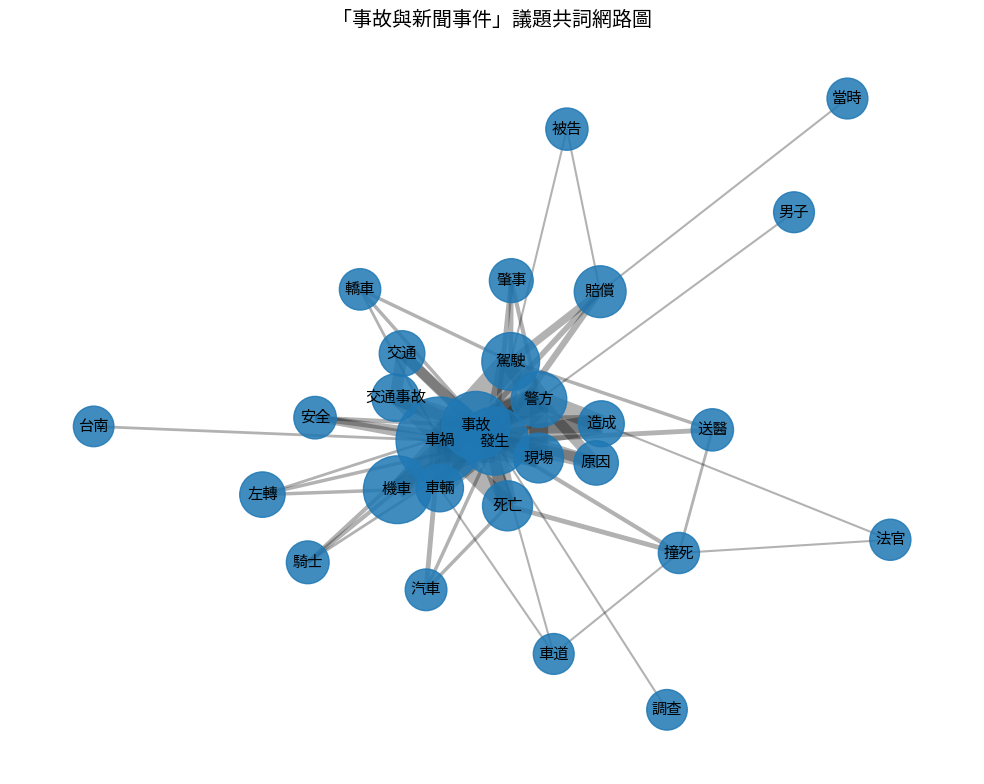

In [54]:


target_topic = "事故與新聞事件"

df_topic_network = df[df["main_topic_revised"] == target_topic].copy()

print("指定議題：", target_topic)
print("文章數：", len(df_topic_network))

topic_docs_tokens = []

for text in df_topic_network["token_text"].fillna("").astype(str):
    words = []

    for w in text.split():
        w = w.strip()

        if not w:
            continue

        if re.fullmatch(r"\d+", w):
            continue

        if w in extra_stopwords_network:
            continue

        if len(w) < 2 and w not in domain_keep_words:
            continue

        words.append(w)

    topic_docs_tokens.append(words)

topic_all_tokens = []
for words in topic_docs_tokens:
    topic_all_tokens.extend(words)

topic_token_freq = Counter(topic_all_tokens)

TOP_N_TERMS_TOPIC = 30

topic_top_terms = [
    word for word, count in topic_token_freq.most_common(TOP_N_TERMS_TOPIC)
    if count >= 3
]

topic_top_terms_set = set(topic_top_terms)

topic_edge_counter = Counter()

for words in topic_docs_tokens:
    filtered_words = [w for w in words if w in topic_top_terms_set]

    filtered_words = sorted(
        set(filtered_words),
        key=lambda x: topic_token_freq[x],
        reverse=True
    )[:8]

    for w1, w2 in combinations(sorted(filtered_words), 2):
        topic_edge_counter[(w1, w2)] += 1

G_topic = nx.Graph()

for word in topic_top_terms:
    G_topic.add_node(word, frequency=topic_token_freq[word])

MIN_CO_OCCUR_TOPIC = 3

for (w1, w2), weight in topic_edge_counter.items():
    if weight >= MIN_CO_OCCUR_TOPIC:
        G_topic.add_edge(w1, w2, weight=weight)

# 每個節點保留前 3 條強邊
edges_to_keep = set()

for node in G_topic.nodes():
    neighbors = []

    for neighbor in G_topic.neighbors(node):
        weight = G_topic[node][neighbor]["weight"]
        neighbors.append((node, neighbor, weight))

    neighbors = sorted(neighbors, key=lambda x: x[2], reverse=True)

    for u, v, w in neighbors[:3]:
        edges_to_keep.add(tuple(sorted([u, v])))

G_topic_sparse = nx.Graph()

for node in G_topic.nodes():
    G_topic_sparse.add_node(node, frequency=G_topic.nodes[node]["frequency"])

for u, v in edges_to_keep:
    if G_topic.has_edge(u, v):
        G_topic_sparse.add_edge(u, v, weight=G_topic[u][v]["weight"])

G_topic_sparse.remove_nodes_from(list(nx.isolates(G_topic_sparse)))

print("子網路節點數：", G_topic_sparse.number_of_nodes())
print("子網路邊數：", G_topic_sparse.number_of_edges())

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    G_topic_sparse,
    k=0.9,
    seed=2026,
    iterations=100
)

node_sizes = [
    300 + G_topic_sparse.nodes[n]["frequency"] * 12
    for n in G_topic_sparse.nodes()
]

edge_widths = [
    max(0.8, G_topic_sparse[u][v]["weight"] / 2)
    for u, v in G_topic_sparse.edges()
]

nx.draw_networkx_nodes(
    G_topic_sparse,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G_topic_sparse,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_labels(
    G_topic_sparse,
    pos,
    font_family="Noto Sans CJK JP",
    font_size=11
)

plt.title(f"「{target_topic}」議題共詞網路圖")
plt.axis("off")
plt.tight_layout()

safe_topic_name = target_topic.replace("／", "_").replace("/", "_")
plt.savefig(
    FIGURE_DIR / f"D_Coword_network_topic_{safe_topic_name}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 共詞網路分析說明

共詞網路圖可以呈現交通安全討論中的核心詞彙與詞彙關係。若某個詞具有較高 degree centrality，代表它與許多不同詞一起出現，可能是整體討論中的核心概念；若某個詞具有較高 betweenness centrality，代表它可能連接不同議題群，例如同時連到行人、安全、事故、政策等詞。這種方法可補足單純詞頻分析，因為它不只看詞出現多少次，也看詞與詞之間的關係。

## D8. 方法四：NER 實體辨識與議題－實體網路

本儲存格的目的，是使用 NER 找出文章中具體被提及的人物、地點、組織或機關。單純詞頻分析只能知道哪些字常出現，但 NER 可以協助辨識文章中討論到的具體對象，例如交通部、市政府、警察、台北、高雄等。後續將這些實體與人工議題類別連接起來，可以建立簡單的議題－實體網路，觀察不同議題常連結到哪些實體。

NER 使用 device： 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Inference: 100%|██████████| 2/2 [00:05<00:00,  2.62s/it]


,doc_index,main_topic_revised,title,entity_word,entity_type
0,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,李多慧,PERSON
1,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,李多慧,PERSON
2,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,李多慧,PERSON
3,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,台灣人,NORP
4,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,日本,GPE
6,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,台灣,GPE
7,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,韓國人,NORP
8,0,其他／未分類,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,台灣人,NORP
9,1,駕駛違規與行為,[新聞] 李多慧化身「交通安全宣導女神」 警局男,李多慧,PERSON
10,1,駕駛違規與行為,[新聞] 李多慧化身「交通安全宣導女神」 警局男,李多慧,PERSON


,entity_word,entity_type,count
91,台灣,GPE,180
366,高雄,GPE,63
217,桃園,GPE,40
244,淡江大橋,FAC,38
182,日本,GPE,34
73,台北,GPE,30
80,台南,GPE,28
135,屏東,GPE,27
68,台中,GPE,26
16,中國,GPE,22


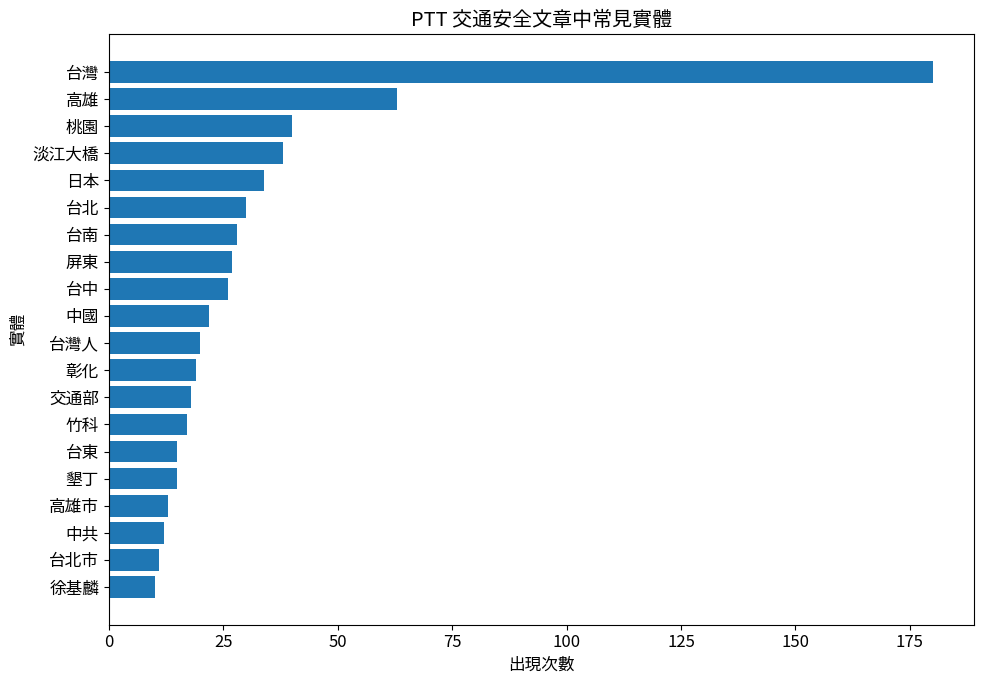

In [36]:
import torch
from ckip_transformers.nlp import CkipNerChunker

# CKIP NER 在 CPU 會比較慢，因此可限制文件數；若 Colab 有 GPU 可調高
MAX_NER_DOCS = min(len(df), 300)

df_ner = df.copy().reset_index(drop=True).iloc[:MAX_NER_DOCS].copy()

# 取前 300 字，降低執行時間，也避免文章過長
ner_texts = (
    df_ner["title"].fillna("").astype(str) + "。" +
    df_ner["clean_text"].fillna("").astype(str).str[:300]
).tolist()

device = 0 if torch.cuda.is_available() else -1
print("NER 使用 device：", device)

ner_driver = CkipNerChunker(
    model_name="ckiplab/bert-base-chinese-ner",
    device=device
)

ner_results = ner_driver(ner_texts)

entity_rows = []

for i, entities in enumerate(ner_results):
    for ent in entities:
        entity_rows.append({
            "doc_index": i,
            "main_topic_revised": df_ner.loc[i, "main_topic_revised"],
            "title": df_ner.loc[i, "title"],
            "entity_word": ent.word,
            "entity_type": ent.ner
        })

entity_df = pd.DataFrame(entity_rows)

# 篩選較適合社會議題分析的實體類型
target_entity_types = ["PERSON", "ORG", "GPE", "LOC", "NORP", "FAC"]

if len(entity_df) > 0:
    entity_df = entity_df[entity_df["entity_type"].isin(target_entity_types)].copy()
    entity_df["entity_word"] = entity_df["entity_word"].astype(str).str.strip()
    entity_df = entity_df[entity_df["entity_word"].str.len() >= 2]

display(entity_df.head(20))

entity_count = (
    entity_df
    .groupby(["entity_word", "entity_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(entity_count.head(30))

# 畫出最常出現實體
top_entities = entity_count.head(20).sort_values("count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_entities["entity_word"], top_entities["count"])
plt.xlabel("出現次數")
plt.ylabel("實體")
plt.title("PTT 交通安全文章中常見實體")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_NER_top_entities.png", dpi=300, bbox_inches="tight")
plt.show()

entity_df.to_csv(ADV_OUTPUT_DIR / "D_NER_entities.csv", index=False, encoding="utf-8-sig")
entity_count.to_csv(ADV_OUTPUT_DIR / "D_NER_entity_count.csv", index=False, encoding="utf-8-sig")

## D9. 議題－實體網路圖

本儲存格的目的，是將 NER 結果轉換成圖形分析。這裡把「議題類別」與「實體」都視為節點，如果某個實體出現在某個議題類別的文章中，就建立一條邊。這樣可以觀察不同交通安全議題常連結到哪些地點、機關或組織，也能呈現交通安全討論背後的公共治理與社會場域。

,main_topic_revised,entity_word,count
257,行人路權與安全,台灣,92
35,事故與新聞事件,台灣,56
375,行人路權與安全,高雄,37
81,事故與新聞事件,桃園,30
184,執法與政策,屏東,25
326,行人路權與安全,淡江大橋,24
300,行人路權與安全,日本,22
422,駕駛違規與行為,台灣,20
282,行人路權與安全,彰化,18
339,行人路權與安全,竹科,17


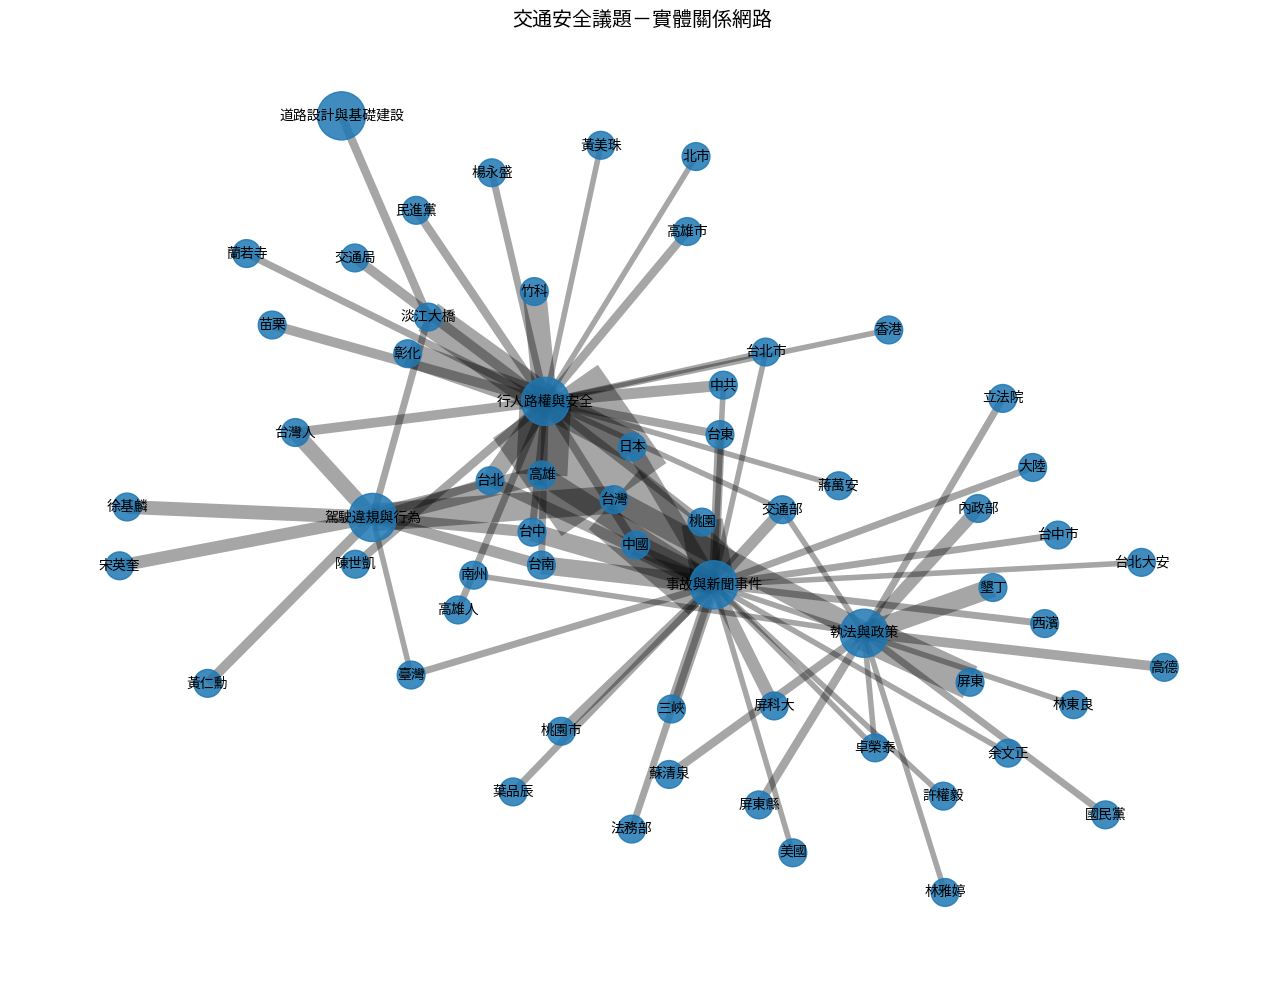

/content/ptt_traffic_safety_project/outputs/advanced_methods/D_topic_entity_network_interactive.html
互動式議題－實體網路圖已輸出： /content/ptt_traffic_safety_project/outputs/advanced_methods/D_topic_entity_network_interactive.html


In [37]:
if len(entity_df) == 0:
    print("NER 沒有擷取到足夠實體，請調高 MAX_NER_DOCS 或確認 CKIP 是否正確執行。")
else:
    topic_entity = (
        entity_df
        .groupby(["main_topic_revised", "entity_word"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    # 只取較常出現的實體，避免圖太亂
    topic_entity_top = topic_entity[topic_entity["count"] >= 2].copy()

    # 若太多，取前 80 條邊
    topic_entity_top = topic_entity_top.head(80)

    display(topic_entity_top.head(30))

    G_entity = nx.Graph()

    topic_nodes = topic_entity_top["main_topic_revised"].unique().tolist()
    entity_nodes = topic_entity_top["entity_word"].unique().tolist()

    for topic in topic_nodes:
        G_entity.add_node(topic, node_type="topic")

    for entity in entity_nodes:
        G_entity.add_node(entity, node_type="entity")

    for _, row in topic_entity_top.iterrows():
        G_entity.add_edge(row["main_topic_revised"], row["entity_word"], weight=row["count"])

    plt.figure(figsize=(13, 10))
    pos = nx.spring_layout(G_entity, k=0.65, seed=2026)

    node_sizes = []
    for node in G_entity.nodes():
        if G_entity.nodes[node]["node_type"] == "topic":
            node_sizes.append(1200)
        else:
            node_sizes.append(400)

    nx.draw_networkx_nodes(G_entity, pos, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(
        G_entity,
        pos,
        width=[G_entity[u][v]["weight"] for u, v in G_entity.edges()],
        alpha=0.35
    )
    nx.draw_networkx_labels(G_entity, pos, font_family="Noto Sans CJK JP", font_size=10)

    plt.title("交通安全議題－實體關係網路")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "D_Topic_entity_network_static.png", dpi=300, bbox_inches="tight")
    plt.show()

    topic_entity.to_csv(ADV_OUTPUT_DIR / "D_topic_entity_edges.csv", index=False, encoding="utf-8-sig")

    net_entity = Network(notebook=True, cdn_resources="in_line", height="700px", width="100%")

    for node in G_entity.nodes():
        node_type = G_entity.nodes[node]["node_type"]
        size = 25 if node_type == "topic" else 12
        net_entity.add_node(
            node,
            label=node,
            value=size,
            title=f"{node}<br>類型：{node_type}"
        )

    for u, v, data in G_entity.edges(data=True):
        net_entity.add_edge(u, v, value=data["weight"], title=f"共同出現次數：{data['weight']}")

    topic_entity_html_path = ADV_OUTPUT_DIR / "D_topic_entity_network_interactive.html"
    net_entity.show(str(topic_entity_html_path))
    print("互動式議題－實體網路圖已輸出：", topic_entity_html_path)
    HTML(str(topic_entity_html_path))

,entity_word,entity_type,count
1,高雄,GPE,63
2,桃園,GPE,40
3,淡江大橋,FAC,38
5,台北,GPE,30
6,台南,GPE,28
7,屏東,GPE,27
8,台中,GPE,26
11,彰化,GPE,19
12,交通部,ORG,18
13,竹科,ORG,17


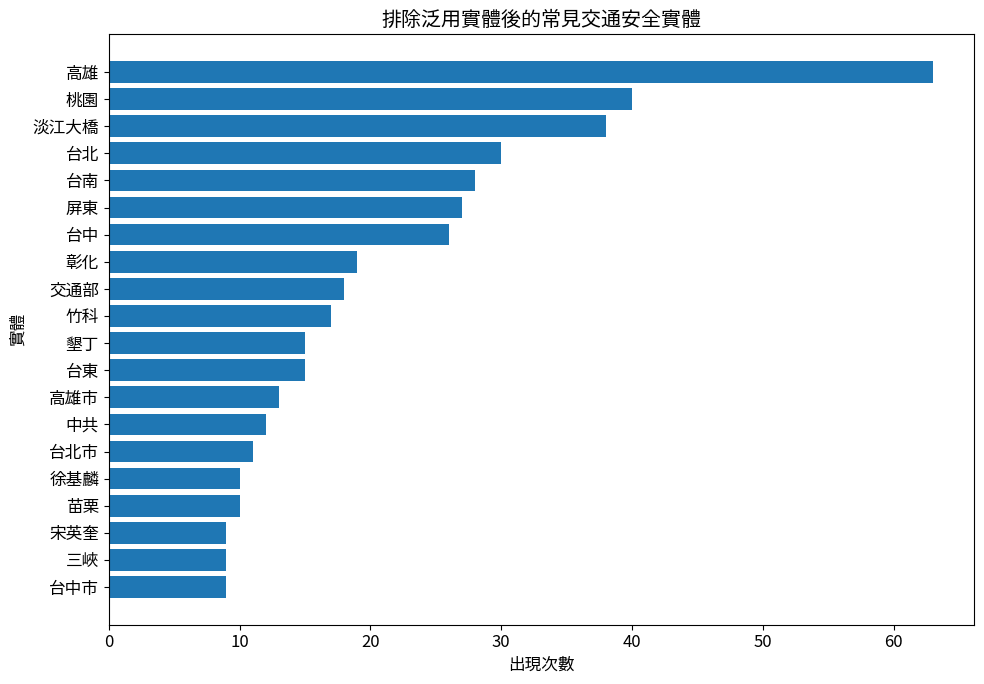

排除泛用實體後的 NER 結果已儲存完成


In [38]:
entity_count = pd.read_csv(ADV_OUTPUT_DIR / "D_NER_entity_count.csv")

generic_entities = set([
    "台灣", "台灣人", "中國", "日本", "美國", "國外", "外國"
])

entity_count_filtered = entity_count[
    ~entity_count["entity_word"].isin(generic_entities)
].copy()

entity_count_filtered = entity_count_filtered.sort_values("count", ascending=False)

display(entity_count_filtered.head(20))

top_entities_filtered = entity_count_filtered.head(20).sort_values("count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_entities_filtered["entity_word"], top_entities_filtered["count"])
plt.xlabel("出現次數")
plt.ylabel("實體")
plt.title("排除泛用實體後的常見交通安全實體")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_NER_top_entities_filtered.png", dpi=300, bbox_inches="tight")
plt.show()

entity_count_filtered.to_csv(
    ADV_OUTPUT_DIR / "D_NER_entity_count_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

print("排除泛用實體後的 NER 結果已儲存完成")

,entity_type,count
1,GPE,737
5,PERSON,229
4,ORG,183
0,FAC,92
3,NORP,69
2,LOC,68


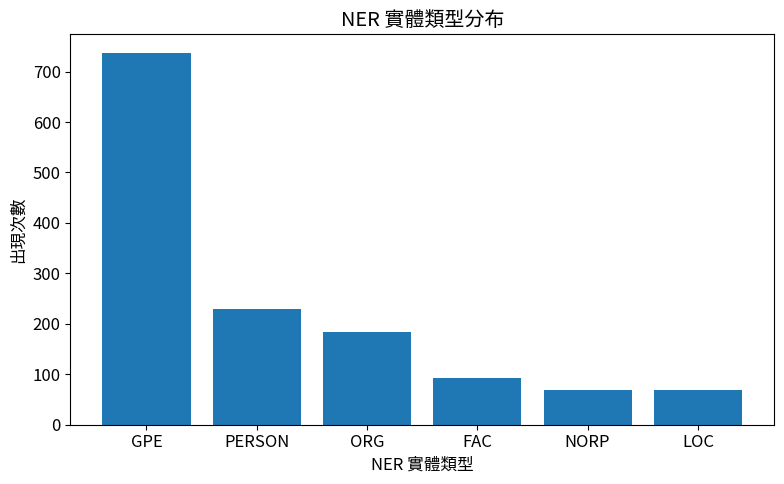

In [39]:

# D8 補充：NER 實體類型分布


entity_df = pd.read_csv(ADV_OUTPUT_DIR / "D_NER_entities.csv")

entity_type_summary = (
    entity_df
    .groupby("entity_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(entity_type_summary)

plt.figure(figsize=(8, 5))
plt.bar(entity_type_summary["entity_type"], entity_type_summary["count"])
plt.xlabel("NER 實體類型")
plt.ylabel("出現次數")
plt.title("NER 實體類型分布")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_NER_entity_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

entity_type_summary.to_csv(
    ADV_OUTPUT_DIR / "D_NER_entity_type_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,agency,count
16,警方,110
14,警察,89
10,民進黨,66
0,中央,55
2,交通部,41
6,國民黨,37
1,交通局,28
8,市政府,26
12,立法院,23
15,警察局,20


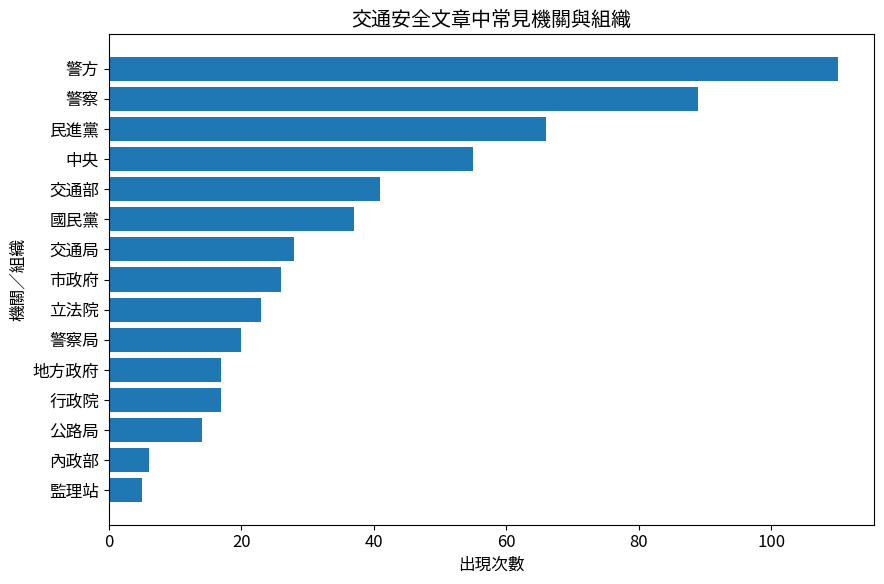

,main_topic_revised,agency,count
11,事故與新聞事件,警方,49
82,駕駛違規與行為,警察,24
21,公共運輸與通勤,民進黨,24
78,駕駛違規與行為,民進黨,23
42,執法與政策,警察,22
84,駕駛違規與行為,警方,21
58,行人路權與安全,警方,20
9,事故與新聞事件,警察,16
56,行人路權與安全,警察,14
12,公共運輸與通勤,中央,13


In [40]:
# =========================
# D8 補充：機關／組織關鍵字分析
# 用來補足 NER 偏向地名的問題
# =========================

agency_keywords = [
    "交通部", "市政府", "北市府", "高市府", "警察", "警方",
    "警察局", "交通局", "公路局", "監理站", "立法院",
    "民進黨", "國民黨", "中央", "地方政府", "行政院",
    "內政部", "道安會", "公運處", "捷運局", "公車處"
]

agency_rows = []

for i, row in df.iterrows():
    text = str(row["clean_text"])
    title = str(row["title"])

    full_text = title + " " + text

    for agency in agency_keywords:
        if agency in full_text:
            agency_rows.append({
                "title": row["title"],
                "main_topic_revised": row["main_topic_revised"],
                "agency": agency
            })

agency_df = pd.DataFrame(agency_rows)

if len(agency_df) == 0:
    print("沒有命中機關／組織關鍵字，請檢查 agency_keywords。")
else:
    agency_count = (
        agency_df
        .groupby("agency")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(agency_count)

    top_agency = agency_count.head(15).sort_values("count", ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(top_agency["agency"], top_agency["count"])
    plt.xlabel("出現次數")
    plt.ylabel("機關／組織")
    plt.title("交通安全文章中常見機關與組織")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "D_agency_keyword_count.png", dpi=300, bbox_inches="tight")
    plt.show()

    agency_topic = (
        agency_df
        .groupby(["main_topic_revised", "agency"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(agency_topic.head(30))

    agency_df.to_csv(
        ADV_OUTPUT_DIR / "D_agency_keyword_records.csv",
        index=False,
        encoding="utf-8-sig"
    )

    agency_count.to_csv(
        ADV_OUTPUT_DIR / "D_agency_keyword_count.csv",
        index=False,
        encoding="utf-8-sig"
    )

    agency_topic.to_csv(
        ADV_OUTPUT_DIR / "D_agency_topic_edges.csv",
        index=False,
        encoding="utf-8-sig"
    )

,entity_type,count
1,GPE,737
5,PERSON,229
4,ORG,183
0,FAC,92
3,NORP,69
2,LOC,68


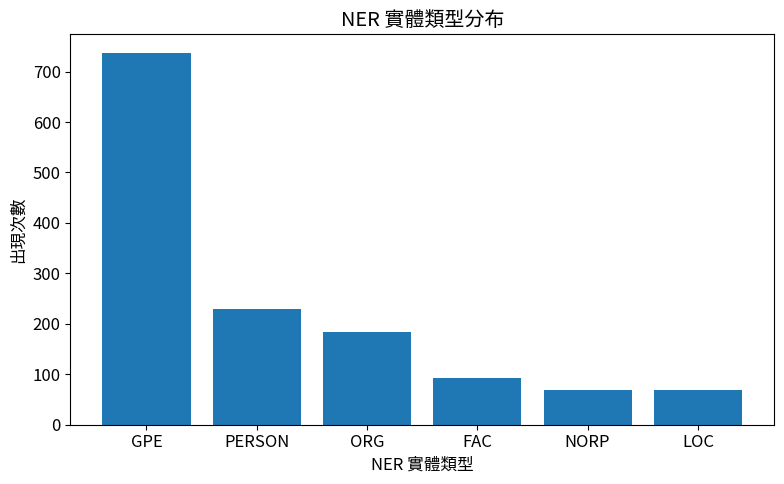

In [45]:
# =========================
# D8-1：NER 實體類型分布
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

entity_df = pd.read_csv(ADV_OUTPUT_DIR / "D_NER_entities.csv")

entity_type_summary = (
    entity_df
    .groupby("entity_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(entity_type_summary)

plt.figure(figsize=(8, 5))
plt.bar(entity_type_summary["entity_type"], entity_type_summary["count"])
plt.xlabel("NER 實體類型")
plt.ylabel("出現次數")
plt.title("NER 實體類型分布")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_NER_entity_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

entity_type_summary.to_csv(
    ADV_OUTPUT_DIR / "D_NER_entity_type_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,entity_word,entity_type,count
11,交通部,ORG,18
124,竹科,ORG,17
4,中共,ORG,12
69,徐基麟,PERSON,10
59,屏科大,ORG,9
16,內政部,ORG,9
103,民進黨,ORG,9
53,宋英奎,PERSON,9
27,卓榮泰,PERSON,8
107,法務部,ORG,7


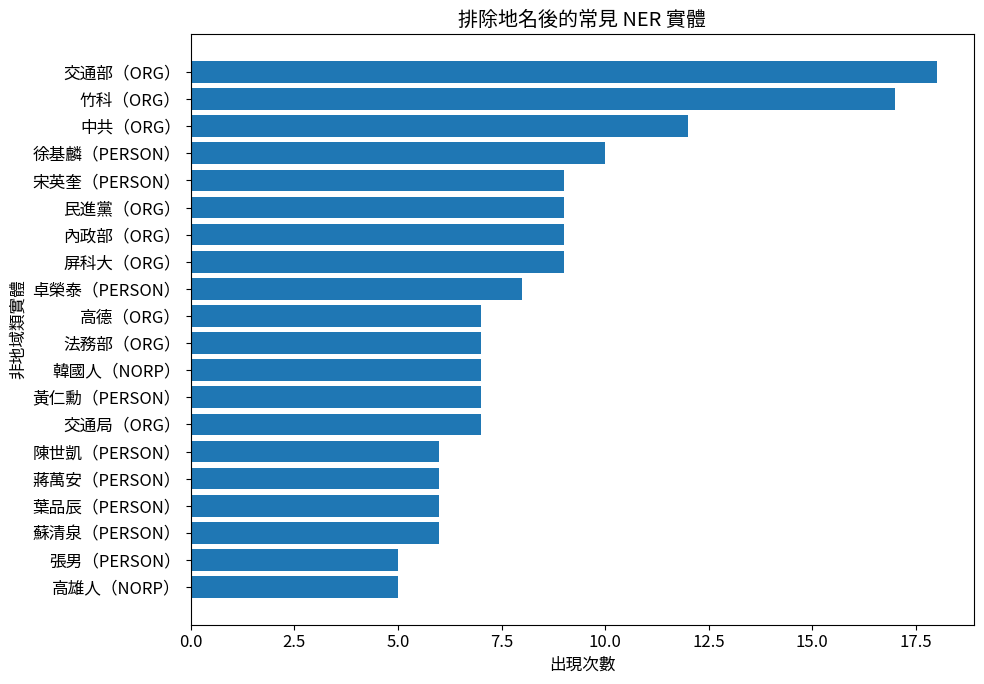

In [46]:
# =========================
# D8-2：排除地域／地點／設施類實體，只看其他實體
# =========================

non_location_types = ["PERSON", "ORG", "NORP"]

entity_non_location = entity_df[
    entity_df["entity_type"].isin(non_location_types)
].copy()

# 移除太泛用的詞
generic_entities = set([
    "台灣", "台灣人", "中國", "日本", "美國", "外國", "國外"
])

entity_non_location = entity_non_location[
    ~entity_non_location["entity_word"].isin(generic_entities)
].copy()

entity_non_location_count = (
    entity_non_location
    .groupby(["entity_word", "entity_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(entity_non_location_count.head(30))

top_non_location = entity_non_location_count.head(20).sort_values("count", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    top_non_location["entity_word"] + "（" + top_non_location["entity_type"] + "）",
    top_non_location["count"]
)
plt.xlabel("出現次數")
plt.ylabel("非地域類實體")
plt.title("排除地名後的常見 NER 實體")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_NER_non_location_entities.png", dpi=300, bbox_inches="tight")
plt.show()

entity_non_location_count.to_csv(
    ADV_OUTPUT_DIR / "D_NER_non_location_entity_count.csv",
    index=False,
    encoding="utf-8-sig"
)

,entity_word,count
8,交通部,18
51,竹科,17
3,中共,12
10,內政部,9
32,屏科大,9
44,民進黨,9
45,法務部,7
7,交通局,7
62,高德,7
26,國民黨,5


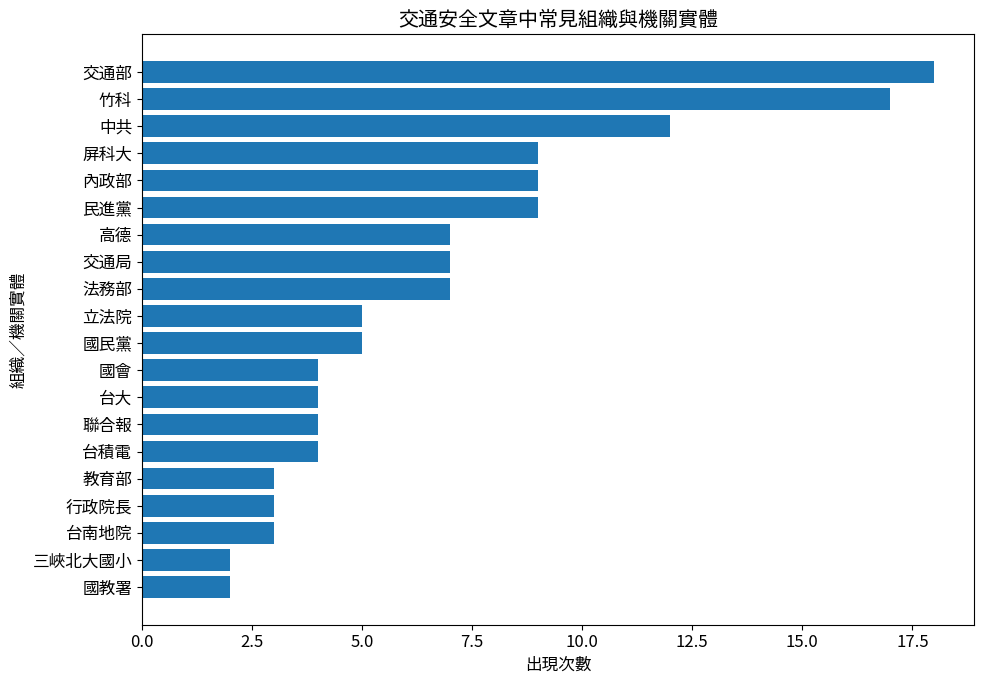

In [47]:
# =========================
# D8-3：組織／機關實體 ORG 分析
# =========================

org_entity = entity_df[
    entity_df["entity_type"] == "ORG"
].copy()

org_count = (
    org_entity
    .groupby("entity_word")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(org_count.head(30))

if len(org_count) > 0:
    top_org = org_count.head(20).sort_values("count", ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(top_org["entity_word"], top_org["count"])
    plt.xlabel("出現次數")
    plt.ylabel("組織／機關實體")
    plt.title("交通安全文章中常見組織與機關實體")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "D_NER_ORG_entities.png", dpi=300, bbox_inches="tight")
    plt.show()

org_count.to_csv(
    ADV_OUTPUT_DIR / "D_NER_ORG_entity_count.csv",
    index=False,
    encoding="utf-8-sig"
)

## D10. 方法五：BERT Embedding 文件語意分群

本儲存格的目的，是使用 BERT-based sentence embedding 將每篇文章轉換成語意向量，並透過降維與分群觀察文章在語意空間中的分布。前面的 LDA 與共詞網路主要以詞彙為基礎，而 BERT Embedding 可以捕捉較高層次的語意相似性。因此，本方法可以檢查同一人工議題類別的文章是否在語意空間中彼此接近，也可以觀察不同議題之間是否有重疊。

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

BERT Embedding KMeans silhouette score： 0.046136487


,title,main_topic_revised,sentiment_label,embedding_cluster,embed_x,embed_y
0,Re: [新聞] 李多慧化身「交通安全宣導女神」 警局男,其他／未分類,中立,0,-0.324715,0.752970
1,[新聞] 李多慧化身「交通安全宣導女神」 警局男,駕駛違規與行為,負向,2,-0.991740,0.488759
2,[新聞] 影／交通安全陷阱？北市庇護島挨批豆腐,行人路權與安全,正向,2,-0.322332,0.850099
3,[問卦] 為啥2008-2016牛奶汽車不降價 不讓行人?,行人路權與安全,正向,5,0.513805,-0.862844
4,Re: [問卦] 台灣被說行人地獄後 交通有改善嗎,行人路權與安全,正向,0,0.628034,0.419799


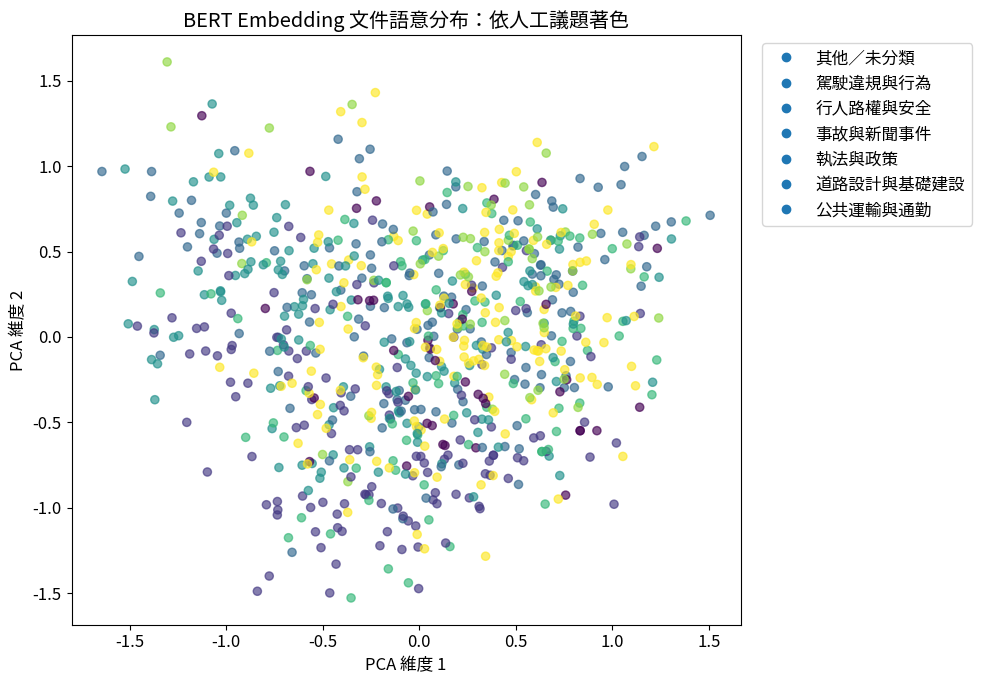

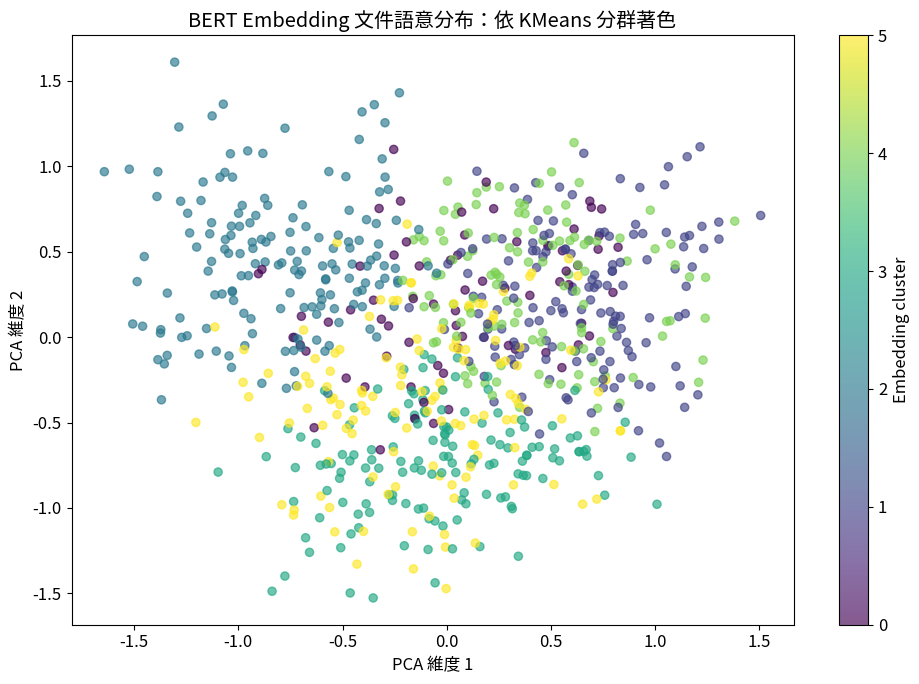

In [41]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 使用前面 BERTopic 已建立的 embedding_model，如果沒有則重新建立
try:
    embedding_model
except NameError:
    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

df_embed = df.copy().reset_index(drop=True)
docs_for_embedding = df_embed["clean_text"].fillna("").astype(str).tolist()

embeddings_for_cluster = embedding_model.encode(
    docs_for_embedding,
    show_progress_bar=True,
    batch_size=32
)

# 使用 PCA 降到 2 維，方便視覺化
pca = PCA(n_components=2, random_state=2026)
embedding_2d = pca.fit_transform(embeddings_for_cluster)

# 使用 KMeans 分群，群數設定為 6，方便和六個人工議題比較
kmeans = KMeans(n_clusters=6, random_state=2026)
embedding_cluster = kmeans.fit_predict(embeddings_for_cluster)

df_embed["embed_x"] = embedding_2d[:, 0]
df_embed["embed_y"] = embedding_2d[:, 1]
df_embed["embedding_cluster"] = embedding_cluster

sil_score = silhouette_score(embeddings_for_cluster, embedding_cluster)
print("BERT Embedding KMeans silhouette score：", sil_score)

display(df_embed[["title", "main_topic_revised", "sentiment_label", "embedding_cluster", "embed_x", "embed_y"]].head())

# 依人工議題類別視覺化
topic_list = df_embed["main_topic_revised"].unique().tolist()
topic_to_num = {topic: i for i, topic in enumerate(topic_list)}
df_embed["topic_num"] = df_embed["main_topic_revised"].map(topic_to_num)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_embed["embed_x"],
    df_embed["embed_y"],
    c=df_embed["topic_num"],
    alpha=0.65,
    s=35
)

plt.xlabel("PCA 維度 1")
plt.ylabel("PCA 維度 2")
plt.title("BERT Embedding 文件語意分布：依人工議題著色")

# 建立 legend
handles = []
for topic, num in topic_to_num.items():
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='', label=topic))
plt.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_BERT_embedding_by_manual_topic.png", dpi=300, bbox_inches="tight")
plt.show()

# 依 KMeans 分群結果視覺化
plt.figure(figsize=(10, 7))
plt.scatter(
    df_embed["embed_x"],
    df_embed["embed_y"],
    c=df_embed["embedding_cluster"],
    alpha=0.65,
    s=35
)
plt.xlabel("PCA 維度 1")
plt.ylabel("PCA 維度 2")
plt.title("BERT Embedding 文件語意分布：依 KMeans 分群著色")
plt.colorbar(label="Embedding cluster")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_BERT_embedding_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

df_embed.to_csv(ADV_OUTPUT_DIR / "D_BERT_embedding_clusters.csv", index=False, encoding="utf-8-sig")

In [42]:
# =========================
# D5 補充：BERTopic 主題人工命名
# =========================

bertopic_info = pd.read_csv(ADV_OUTPUT_DIR / "D_BERTopic_topic_info.csv")

bertopic_manual_labels = {
    0: "汽機車與道路空間",
    1: "交通事故與警方處理",
    2: "酒駕毒駕與政治攻防",
    3: "違規、測速與執法",
    4: "公共運輸與自駕公車",
    5: "車禍賠償與行人風險"
}

bertopic_info["manual_label"] = bertopic_info["Topic"].map(bertopic_manual_labels)

display(bertopic_info[["Topic", "Count", "Name", "manual_label"]])

bertopic_info.to_csv(
    ADV_OUTPUT_DIR / "D_BERTopic_topic_info_labeled.csv",
    index=False,
    encoding="utf-8-sig"
)

print("BERTopic 人工命名結果已儲存完成")

,Topic,Count,Name,manual_label
0,0,173,0_酒駕_違停_警察_民進,汽機車與道路空間
1,1,171,1_機車_汽車_車道_中國,交通事故與警方處理
2,2,133,2_警方_發生_車禍_事故,酒駕毒駕與政治攻防
3,3,106,3_測速_照相_交通_行人,違規、測速與執法
4,4,106,4_公車_捷運_無人_自駕,公共運輸與自駕公車
5,5,83,5_賠償_交通_車禍_行人,車禍賠償與行人風險


BERTopic 人工命名結果已儲存完成


In [43]:
# =========================
# D11 補充：BERT Embedding 分群與人工議題重疊程度
# =========================

embedding_cross = pd.read_csv(
    ADV_OUTPUT_DIR / "D_BERT_embedding_cross_manual_topic.csv",
    index_col=0
)

embedding_cross_ratio = embedding_cross.div(embedding_cross.sum(axis=1), axis=0) * 100

embedding_cluster_summary = []

for manual_topic in embedding_cross_ratio.index:
    max_cluster = embedding_cross_ratio.loc[manual_topic].idxmax()
    max_ratio = embedding_cross_ratio.loc[manual_topic].max()

    embedding_cluster_summary.append({
        "manual_topic": manual_topic,
        "largest_embedding_cluster": max_cluster,
        "largest_cluster_ratio_percent": max_ratio
    })

embedding_cluster_summary = pd.DataFrame(embedding_cluster_summary)

display(embedding_cluster_summary)

embedding_cluster_summary.to_csv(
    ADV_OUTPUT_DIR / "D_BERT_embedding_cluster_overlap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("BERT Embedding 分群重疊摘要已儲存完成")

,manual_topic,largest_embedding_cluster,largest_cluster_ratio_percent
0,事故與新聞事件,2,39.007092
1,公共運輸與通勤,1,35.135135
2,其他／未分類,5,63.414634
3,執法與政策,4,41.304348
4,行人路權與安全,1,30.519481
5,道路設計與基礎建設,4,39.215686
6,駕駛違規與行為,3,37.931034


BERT Embedding 分群重疊摘要已儲存完成


## D11. BERT Embedding 分群與人工議題比較

本儲存格的目的，是比較 BERT 語意分群與人工議題分類是否一致。若某個 embedding cluster 主要由同一人工議題組成，代表該議題在語意上具有一致性；若一個 cluster 混合多種人工議題，代表交通安全討論之間可能存在語意重疊，例如事故文章可能同時涉及行人路權、違規駕駛與政策執法。

embedding_cluster,0,1,2,3,4,5
main_topic_revised,,,,,,
事故與新聞事件,29,3,55,30,21,3
公共運輸與通勤,1,52,20,14,27,34
其他／未分類,2,4,3,2,4,26
執法與政策,1,8,9,22,38,14
行人路權與安全,23,47,39,17,13,15
道路設計與基礎建設,1,16,8,4,20,2
駕駛違規與行為,13,16,26,55,1,34


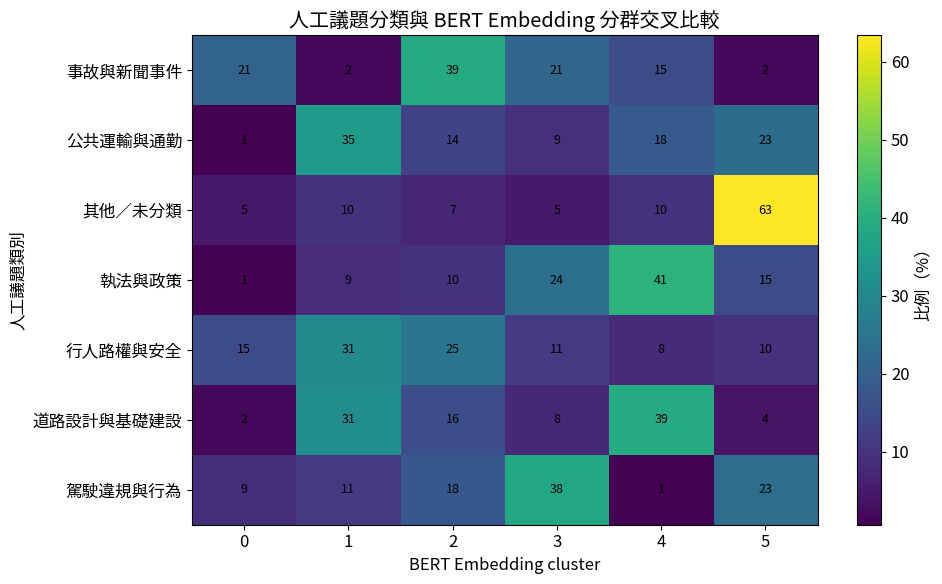

In [44]:
embedding_cross = pd.crosstab(
    df_embed["main_topic_revised"],
    df_embed["embedding_cluster"]
)

display(embedding_cross)

embedding_cross_ratio = embedding_cross.div(embedding_cross.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
plt.imshow(embedding_cross_ratio, aspect="auto")
plt.xticks(range(embedding_cross_ratio.shape[1]), embedding_cross_ratio.columns)
plt.yticks(range(embedding_cross_ratio.shape[0]), embedding_cross_ratio.index)
plt.colorbar(label="比例（%）")
plt.xlabel("BERT Embedding cluster")
plt.ylabel("人工議題類別")
plt.title("人工議題分類與 BERT Embedding 分群交叉比較")

for i in range(embedding_cross_ratio.shape[0]):
    for j in range(embedding_cross_ratio.shape[1]):
        value = embedding_cross_ratio.iloc[i, j]
        if value > 0:
            plt.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_BERT_embedding_cross_manual_topic.png", dpi=300, bbox_inches="tight")
plt.show()

embedding_cross.to_csv(ADV_OUTPUT_DIR / "D_BERT_embedding_cross_manual_topic.csv", encoding="utf-8-sig")

In [55]:


d_advanced_report_final = """
# D. 視覺化的分析結果與解釋

本階段根據 C 階段清理後的 PTT 交通安全與行人路權資料進行視覺化與進階文字分析。除了基本的議題文章數、整體情緒分布與看板互動分析外，本研究也加入課堂中提到的多種分析工具，包含 LDA 主題模型、LDA Intertopic Distance Map、BERTopic 主題模型、BERTopic Topic Map、共詞網路圖、NER 實體辨識，以及 BERT Embedding 文件語意分群。透過這些方法，本研究可以從主題、語意、詞彙關係、實體關係與社群互動等不同角度分析 PTT 使用者如何討論台灣交通安全與行人路權議題。

首先，在基本視覺化方面，資料顯示交通安全討論並非集中於單一議題，而是分散在行人路權與安全、公共運輸與通勤、駕駛違規與行為、事故與新聞事件、執法與政策，以及道路設計與基礎建設等不同面向。整體情緒分布則顯示負向文章比例較高，代表 PTT 使用者在討論交通安全與行人路權時，常伴隨對事故、違規、酒駕、違停與道路環境的不滿。

其次，在 LDA 主題模型方面，本研究原先的模型結果出現「中國」、「美國」、「日本」等國家比較詞，這些詞雖然反映部分文章會將台灣交通環境與其他國家比較，但本研究核心問題是台灣交通安全與行人路權，而非國際比較。因此，修正版 LDA 將國家名稱、地名、新聞格式詞、PTT 格式詞與泛用詞加入停用詞，使主題模型更集中於交通安全核心概念，例如行人、車禍、違停、酒駕、測速、公車、人行道與道路設計等。修正版 LDA 可用來觀察文章在詞袋模型下形成的潛在主題。

第三，本研究補充 LDA Intertopic Distance Map，以視覺化方式觀察 LDA 主題之間的距離。圖中的每個圓圈代表一個主題，圓圈大小代表該主題涵蓋的文章比例，主題之間距離越遠表示內容差異越明顯。若主題距離接近或重疊，則表示交通安全文章中的主題具有交疊性。例如車禍文章可能同時涉及行人路權、駕駛違規、執法政策與道路設計，因此 LDA 主題不一定會完全分離。這個結果提醒本研究在解釋交通安全議題時，不應將各類別視為完全互斥。

第四，在 BERTopic 分析方面，本研究使用 BERT 語意向量進行主題分群，並為模型產生的主題加入人工命名。BERTopic 主題大致可解釋為汽機車與道路空間、交通事故與警方處理、酒駕毒駕與政治攻防、違規測速與執法、公共運輸與自駕公車，以及車禍賠償與行人風險。相較於 LDA，BERTopic 不只依賴詞頻，而是透過語意向量捕捉文章相似性，因此較適合處理 PTT 這類口語化、短文本與跨議題的社群資料。

第五，本研究也補充 BERTopic Topic Map，用來觀察不同 BERTopic 主題在語意空間中的相對距離。若某些主題距離較近，代表它們在語意上具有相似性，例如交通事故可能同時連結到酒駕、警方處理、行人安全與政策執法。BERTopic Topic Map 可作為 LDA Intertopic Distance Map 的補充，兩者分別從詞袋模型與 BERT 語意模型角度呈現主題結構。

第六，在共詞網路分析方面，初步共詞網路圖呈現出過度複雜的結構，主要原因是交通安全文章本身具有高度跨議題特性，例如車禍文章可能同時提到行人、警方、違規、道路、酒駕與政策，因此若直接以全部文章建立共詞網路，詞與詞之間會形成大量連線，導致圖形不易閱讀。此外，前一次共詞網路也受到新聞格式詞與 PTT 格式詞影響，例如「表示」、「指出」、「完整」、「Re」等詞具有較高中心性，但這些詞並不代表交通安全議題本身。

因此，本研究進一步修正共詞網路的建構方式。修正版共詞網路移除新聞模板詞、PTT 回文格式詞、日期數字與泛用詞，並採用稀疏化處理，包括限制節點數量、提高共現門檻、每篇文章只保留較重要詞彙，以及每個節點只保留最強的幾條連線。修正後的共詞網路更適合用來觀察交通安全討論中的核心詞彙與主要連結，例如行人、車禍、酒駕、違停、測速、警察、人行道與公車等詞之間的關係，而不是被過多弱連線或格式詞干擾。

第七，除了全體共詞網路外，本研究也可以針對特定議題建立子網路，例如「行人路權與安全」、「駕駛違規與行為」或「事故與新聞事件」。相較於全體網路，指定議題的共詞子網路能更清楚呈現該議題內部的詞彙結構。例如行人路權相關文章可能更集中於行人、人行道、斑馬線、庇護島與車輛禮讓；駕駛違規類文章則可能更集中於酒駕、違停、測速、罰單與警察執法。這樣的子網路分析能讓圖形結果更容易解釋，也更符合社群網路分析中觀察節點關係與中心性的目的。

第八，在 NER 實體辨識方面，初步結果顯示模型辨識出的實體以地點與行政區為主，例如縣市、道路、橋梁或交通設施。這與交通安全議題本身具有高度地域性有關，因為交通事故、道路建設、公共運輸與執法事件通常會發生在具體地點。不過，如果只看整體實體排行，地名會掩蓋其他具有社會分析意義的實體。因此，本研究進一步補充 NER 實體類型分布、排除地域類實體後的其他實體排行，以及組織／機關實體分析。

第九，由於 NER 模型不一定能穩定辨識「警方」、「交通部」、「市政府」、「交通局」等治理單位，本研究另外使用機關／組織關鍵字分析補足 NER 的限制。此方法可以觀察交通安全討論如何連結到交通部、市政府、警方、交通局、公路局與政治組織等公共治理單位。這使 NER 分析不只停留在地名，而能進一步討論交通安全議題背後的政策執法、政府責任與公共治理問題。

第十，本研究也補充「議題 × 機關／組織」的關聯分析，用來觀察不同交通安全子議題與公共治理單位之間的關係。例如「執法與政策」類文章可能較常連結到交通部、警方、交通局或政府單位；「公共運輸與通勤」類文章可能較常連結到公車、捷運或市政府；「事故與新聞事件」則可能同時連結到警方、地方政府與事故地點。這樣的分析能讓 NER 結果從單純的實體排行，進一步延伸為議題與治理對象之間的關係分析。

第十一，在 BERT Embedding 文件語意分群方面，本研究將每篇文章轉換成語意向量，並使用降維與 KMeans 分群觀察文章在語意空間中的分布。結果顯示，人工議題類別並沒有在語意空間中完全分離，各人工議題的最大 cluster 比例多落在約 30% 至 40% 左右。這代表同一議題內部仍包含多種語意面向，也表示不同交通安全議題之間存在高度重疊。例如事故文章可能同時涉及行人路權、違規駕駛、道路設計與政策執法，因此交通安全討論不應被理解為完全分離的單一主題。

整體而言，D 階段的分析結果顯示，本研究不只使用描述統計與情緒分析，也進一步應用課堂中提到的主題模型、BERT 語意分析、圖形網路分析與 NER 實體辨識方法。修正後的分析流程能避免新聞格式詞、國家比較詞、泛用地名與 PTT 格式詞對模型結果造成干擾，並使分析結果更集中於台灣交通安全與行人路權本身。同時，LDA 與 BERTopic 顯示交通安全文章具有多個潛在主題，共詞網路呈現詞彙之間的連結關係，NER 與機關關鍵字分析呈現議題背後的地點與治理單位，而 BERT Embedding 則顯示不同議題在語意上具有重疊性。這些視覺化與進階分析結果將作為 E 階段結論的依據。
"""

with open(OUTPUT_DIR / "D_advanced_analysis_report_final.md", "w", encoding="utf-8") as f:
    f.write(d_advanced_report_final)

print("D 階段最終版分析報告已輸出：")
print(OUTPUT_DIR / "D_advanced_analysis_report_final.md")

D 階段最終版分析報告已輸出：
/content/ptt_traffic_safety_project/outputs/D_advanced_analysis_report_final.md


# E. 結論

本研究以 PTT 公開文章作為資料來源，分析台灣交通安全與行人路權議題在社群媒體中的討論情形。研究流程包含資料爬蟲、資料清理、議題分類、情緒分析、TF-IDF 關鍵詞分析、主題模型、BERTopic、共詞網路、NER 實體辨識與 BERT Embedding 文件語意分群。整體而言，本研究發現 PTT 對交通安全的討論具有明顯的負向情緒、事件驅動特性，以及跨議題重疊現象。

## E1. 主要討論焦點

從議題文章數來看，本研究目前分析資料共 772 筆文章。文章數最多的是「行人路權與安全」，共有 154 篇，占約 19.9%；其次是「公共運輸與通勤」148 篇，占約 19.2%；「駕駛違規與行為」145 篇，占約 18.8%；「事故與新聞事件」141 篇，占約 18.3%。這四類合計占整體資料大多數，顯示 PTT 對交通安全的討論主要集中在行人安全、公共運輸、違規駕駛與交通事故。

相較之下，「執法與政策」有 92 篇，占約 11.9%；「道路設計與基礎建設」有 51 篇，占約 6.6%。這表示雖然交通安全問題本身也牽涉政策、道路設計與基礎建設，但社群討論更容易集中在較貼近日常經驗或較容易引發情緒反應的事件，例如車禍、酒駕、違停、行人事故與公共運輸爭議。

## E2. 情緒分析結論

整體情緒分布顯示，負向文章共有 379 篇，占約 49.1%；中立文章共有 235 篇，占約 30.4%；正向文章共有 158 篇，占約 20.5%。這代表 PTT 使用者在討論交通安全與行人路權議題時，整體情緒偏向負面。

不同議題的情緒差異相當明顯。「駕駛違規與行為」共有 145 篇文章，其中 135 篇為負向，負向比例約 93.1%，是所有議題中負向情緒最集中的類別。這表示只要文章涉及酒駕、違停、違規、超速、危險駕駛等內容，社群反應通常會明顯偏負面。「事故與新聞事件」共有 141 篇文章，其中 116 篇為負向，負向比例約 82.3%，顯示車禍、死亡、受傷、肇事與事故責任等內容也容易引發強烈負面情緒。

相較之下，「公共運輸與通勤」的中立文章比例較高，共 93 篇，占該類別約 62.8%。這表示公共運輸相關文章較常是政策資訊、通勤經驗、建設規劃或交通服務討論，不一定直接帶有強烈情緒。「道路設計與基礎建設」的正向比例相對較高，共 21 篇正向文章，占約 41.2%，可能與改善道路、人行道、交通工程與公共建設等內容有關。

## E3. 看板與社群反應結論

從看板來源來看，Gossiping 是本研究資料的主要來源，共 433 篇，占約 56.1%；其次是 HatePolitics，共 186 篇，占約 24.1%；car 看板有 114 篇，占約 14.8%；biker 與 Road 看板則分別為 28 篇與 11 篇。這表示交通安全與行人路權議題在 PTT 上主要仍是由一般大眾討論與政治政策討論所帶動。

不過，若觀察平均互動量，biker 與 car 看板的單篇文章平均互動數較高。biker 平均互動數約 90.0，car 約 74.9，高於 Gossiping 與 HatePolitics。這代表雖然汽機車相關看板文章數較少，但當交通安全議題出現在汽機車使用者社群時，通常會引發更強的討論反應。這也符合交通安全議題的特性，因為汽車與機車使用者本身就是道路系統中的重要參與者，對違規、道路設計、行人路權與執法議題會有更直接的經驗與立場。

## E4. 主題模型與 BERTopic 結論

LDA 主題模型經過修正後，已排除中國、美國、日本等國家比較詞，以及新聞格式詞與 PTT 格式詞。修正版 LDA 的 coherence 指標顯示，5 個主題的 coherence 最高，約為 0.418。這表示在詞袋模型下，PTT 交通安全文章可以被歸納成數個潛在主題，但主題邊界並非完全清楚。LDA 的代表詞包含汽車、測速、交通、安全、行人、機車、車道、酒駕、車禍等，顯示模型確實有捕捉到交通安全的核心詞彙。

BERTopic 則從語意向量角度補充 LDA 的不足。根據 BERTopic 的代表詞，目前可重新解讀為以下幾類主題：酒駕違停與政治討論、汽機車與道路空間、交通事故與警方處理、測速與行人設施、公共運輸與自駕公車、車禍賠償與行人風險。這些主題比 LDA 更能呈現 PTT 文章的語意分群，也顯示交通安全討論不只是單純事故或行人問題，而是同時包含違規執法、政治責任、公共運輸、道路設計與賠償制度等多個層面。

LDA Intertopic Distance Map 與 BERTopic Topic Map 也顯示，交通安全主題之間具有一定程度的重疊。這是合理的，因為一篇交通事故文章可能同時涉及行人安全、酒駕、警方處理、道路設計與政府政策。因此，本研究不應將各個議題視為完全互斥，而應理解為彼此交疊的社群討論面向。

## E5. 共詞網路結論

共詞網路分析顯示，交通安全討論中的核心詞包含交通、機車、車禍、警方、安全、車道、駕駛等。修正版共詞網路已移除新聞格式詞、PTT 格式詞、日期數字與泛用詞，並使用稀疏化方法降低圖形複雜度。結果顯示，「交通」具有最高 degree centrality 與 betweenness centrality，代表它不只是高頻詞，也在不同詞彙群之間扮演連接角色。

從共詞網路可以看出，交通安全議題並不是由單一詞彙或單一事件構成，而是由多個詞彙群共同形成。例如「車禍、警方、事故、駕駛」反映事故處理脈絡；「機車、汽車、車道、道路」反映道路使用與空間配置；「行人、人行道、斑馬線、安全」則反映行人路權與道路設計。共詞網路補足了單純詞頻或 TF-IDF 的不足，因為它不只呈現詞彙出現次數，也呈現詞彙之間的連結關係。

## E6. NER 與機關／組織分析結論

NER 實體辨識結果顯示，模型辨識出的實體以 GPE 地理政治實體最多，共 737 次；其次為 PERSON 人物實體 229 次、ORG 組織實體 183 次、FAC 設施實體 92 次、NORP 族群或政治群體 69 次、LOC 地點實體 68 次。這表示交通安全討論具有明顯地域性，許多文章會提到具體縣市、道路、橋梁、事故地點或交通設施。

不過，若只看地名，容易忽略交通安全背後的治理對象。因此，本研究進一步排除地域類實體，觀察其他實體與機關組織。非地域實體中出現交通部、竹科、內政部、民進黨、人物姓名等，代表交通安全討論不只關注事故地點，也會連結到政策機關、產業園區、政治組織與特定人物。

機關／組織關鍵字分析進一步顯示，警方出現 110 次，警察出現 89 次，民進黨出現 66 次，中央出現 55 次，交通部出現 41 次，國民黨出現 37 次，交通局出現 28 次，市政府出現 26 次。這表示交通安全議題在 PTT 上經常被連結到執法機關、政府部門與政治責任。換句話說，社群使用者並不只是討論個別事故，也會討論交通治理、政策責任與政黨立場。

## E7. BERT Embedding 語意分群結論

BERT Embedding 分群結果顯示，人工議題類別在語意空間中並沒有完全分離。各人工議題的最大 cluster 比例大多落在約 30% 至 41% 之間，例如「事故與新聞事件」最大 cluster 約 39.0%，「公共運輸與通勤」約 35.1%，「執法與政策」約 41.3%，「行人路權與安全」約 30.5%，「道路設計與基礎建設」約 39.2%，「駕駛違規與行為」約 37.9%。

這代表交通安全議題具有高度語意重疊性。即使人工分類將文章分為不同類別，實際文章內容仍可能同時涉及多個面向。例如事故文章可能同時包含行人路權、酒駕違規、警方處理與道路設計；公共運輸文章也可能涉及政策規劃、預算、道路空間與政治討論。因此，BERT Embedding 的結果支持本研究在 D 階段的觀察：交通安全議題不是彼此完全分離的類別，而是相互交疊的社會議題網絡。

## E8. 整體結論

綜合 C 與 D 階段分析結果，本研究可以得到三個主要結論。

第一，PTT 對台灣交通安全與行人路權的討論主要集中在行人安全、公共運輸、駕駛違規與交通事故。這些議題都和民眾日常交通經驗密切相關，因此較容易成為社群討論焦點。

第二，整體社群情緒偏向負面，尤其是駕駛違規與事故新聞最容易引發負向情緒。這表示交通安全議題在 PTT 上常被視為需要改善的社會問題，而非單純交通資訊交流。酒駕、違停、車禍、死亡、肇事與行人安全不足等內容，是負向情緒的重要來源。

第三，多種進階分析方法共同顯示，交通安全議題具有跨議題特性。LDA 與 BERTopic 顯示文章存在多個潛在主題；共詞網路顯示核心詞彙彼此高度連結；NER 與機關組織分析顯示交通安全討論同時涉及地點、機關與政策治理；BERT Embedding 則顯示人工議題在語意空間中並未完全分離。因此，交通安全與行人路權應被理解為一個結合事故、道路設計、公共運輸、執法政策與社會情緒的複合型公共議題。

## E9. 研究限制與未來改善

本研究仍有幾項限制。第一，資料來源主要來自 PTT，因此結果只能代表 PTT 公開文章中的討論傾向，不能直接推論為全體台灣民眾意見。第二，情緒分析使用字典式方法，雖然具有透明且容易解釋的優點，但無法完全處理反諷、玩笑語氣、複雜語境或 PTT 常見的特殊用語。第三，議題分類與機關關鍵字分析仍部分依賴人工字典，可能受到關鍵字設計影響。第四，LDA 與 BERTopic 雖然可以自動產生主題，但模型結果仍需要人工解讀，因此主題命名可能具有一定主觀性。第五，NER 對中文社群文本的辨識仍有限，尤其是政府機關、網路暱稱與政治詞彙不一定能被穩定辨識。

未來研究可以從幾個方向改善。第一，可以加入 Dcard、Facebook 公開粉專留言或新聞留言等不同平台，比較不同社群平台對交通安全的討論差異。第二，可以使用人工標註資料訓練更適合 PTT 語境的情緒分類模型，以改善字典式情緒分析的限制。第三，可以進一步將時間序列與重大新聞事件結合，分析哪些事故或政策最容易引發討論高峰。第四，可以針對特定子議題，例如行人路權、酒駕、違停或公共運輸，進行更深入的子網路分析與主題模型比較。第五，可以建立更完整的交通安全專用詞典與實體字典，使主題分類、NER 與共詞網路結果更穩定。
